# 03 ML Pipeline: Customer Tribe Discovery

This notebook starts from the prepared parquet outputs created by Notebook 02. It does not repeat raw loading, cleaning, or exploratory data quality work from Notebooks 01 and 02.

The goal is to discover product-first customer tribes from purchase behavior. The client hypothesis is roughly 10-15 tribes, but that range is not used as a modeling constraint. The final recommendation is selected from metrics, stability-ready diagnostics, cluster balance, product/sector lift interpretability, and business usefulness.

## Table of Contents

| Section | What it covers |
|---|---|
| [Stage 0: Load Prepared Data](#stage-0) | Sets the run mode, validates paths, loads prepared transactions, and previews the input data. |
| [Stage 0.5: Expensive Cache Audit](#stage-0-5) | Checks whether Stage 1-6 artifacts can be reused safely from cache. |
| [Stage 1: Basket Construction](#stage-1) | Converts checkout records into basket sentences for product embedding training. |
| [Stage 2: Item2Vec Product Embeddings](#stage-2) | Builds or loads product embeddings from product co-purchase behavior. |
| [Stage 3: Product Embedding Validation](#stage-3) | Reviews product-neighbor diagnostics and embedding quality checks. |
| [Stage 4: Customer Embeddings](#stage-4) | Creates product-first customer embeddings from purchased products and quantities. |
| [Stage 5: Official Feature Set](#stage-5) | Builds the official product/quantity feature set and supporting non-demographic behavior summaries. |
| [Stage 6: Hard UMAP-HDBSCAN Core Tribe Discovery](#stage-6) | Builds the UMAP customer manifold, runs hard HDBSCAN, and exports core-tribe diagnostics. |
| [Stage 6.6: Cluster Stability and Profile Readiness](#stage-6-6) | Tests cluster-level stability, confidence, and readiness before profiling. |
| [Stage 7: Final Tribe Handoff](#stage-7) | Turns the selected clustering solution into an organized final story, evidence index, and PNG tribe-card gallery. |

Tribe discovery is documented as a clear late-stage progression:

| Layer | Pipeline stage | What it proves | Main outputs |
|---|---|---|---|
| 1. Product-only modeling signal | Stages 4-5 | Official clustering uses product identity and quantity, not demographics, spend, or behavior KPIs. | Customer embeddings, feature-set diagnostics |
| 2. Organic core tribes | Stage 6.1-6.6 | Dense product-purchase behavior groups exist without forcing every customer into a tribe, and the retained clusters are checked before profiling. | UMAP representation, hard HDBSCAN assignments, representation/density evidence, stability/readiness report |
| 3. Final tribe handoff | Stage 7 | The selected solution is read through an ordered ladder: readiness, product distinctiveness, commercial context, and caveats. | Final story, tribe cards, profile readiness table, comparison tables, evidence dashboard |
| 4. Supporting proof | Stage 7 | Detailed product and comparison artifacts support specific claims without crowding the main read. | Product summaries, tribe comparison, customer metric context, manifest |

Read the official result in that order: first whether hard organic core tribes exist, then whether Stage 6.6 stability/readiness supports profiling them, then whether the Stage 7 evidence storyline makes them interpretable, distinct, caveated, and profileable. Spend and KPIs are interpretation context only; they are never part of the clustering signal.


<a id="stage-0"></a>

## Stage 0: Load Prepared Data

Notebook 03 consumes `df_combined.parquet`, validates the fields required for ML, and merges product metadata only if the prepared file does not already contain it.

Run mode: dev
Data path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\dev
Model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models
Output path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev
[13:15:16] Stage 0 figures: wrote prepared data overview | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage0_prepared_data_overview.png


# Stage 00: Load Prepared Data

- Mode: `dev`

## Status
- Run mode active: dev
- Mode/path audit passed; dev and prod namespaces are not mixed.
- Prepared transactions loaded from the configured mode path.

## Key Metrics

| Metric | Value |
|---|---|
| mode_path_checks | 29 |
| failed_mode_path_checks | 0 |

## Visual Evidence
- Prepared data overview: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage0_prepared_data_overview.png`

## Artifacts
- Prepared transactions: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\dev\df_combined.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

check,status,exists,reason
str,str,bool,str
"""environment_mode""","""pass""",true,"""CARREFOUR_MODE matches CONFIG.…"
"""src_config_module_mode""","""pass""",true,"""src.config.CONFIG matches note…"
"""prepared_transactions""","""pass""",true,"""path is mode-safe"""
"""outputs_root""","""pass""",true,"""path is mode-safe"""
"""models_root""","""pass""",true,"""path is mode-safe"""
…,…,…,…
"""figures_root""","""pass""",true,"""path is mode-safe"""
"""model_selection_cache_root""","""pass""",true,"""path is mode-safe"""
"""stage_1_6::basket_sentences""","""pass""",true,"""path is mode-safe"""


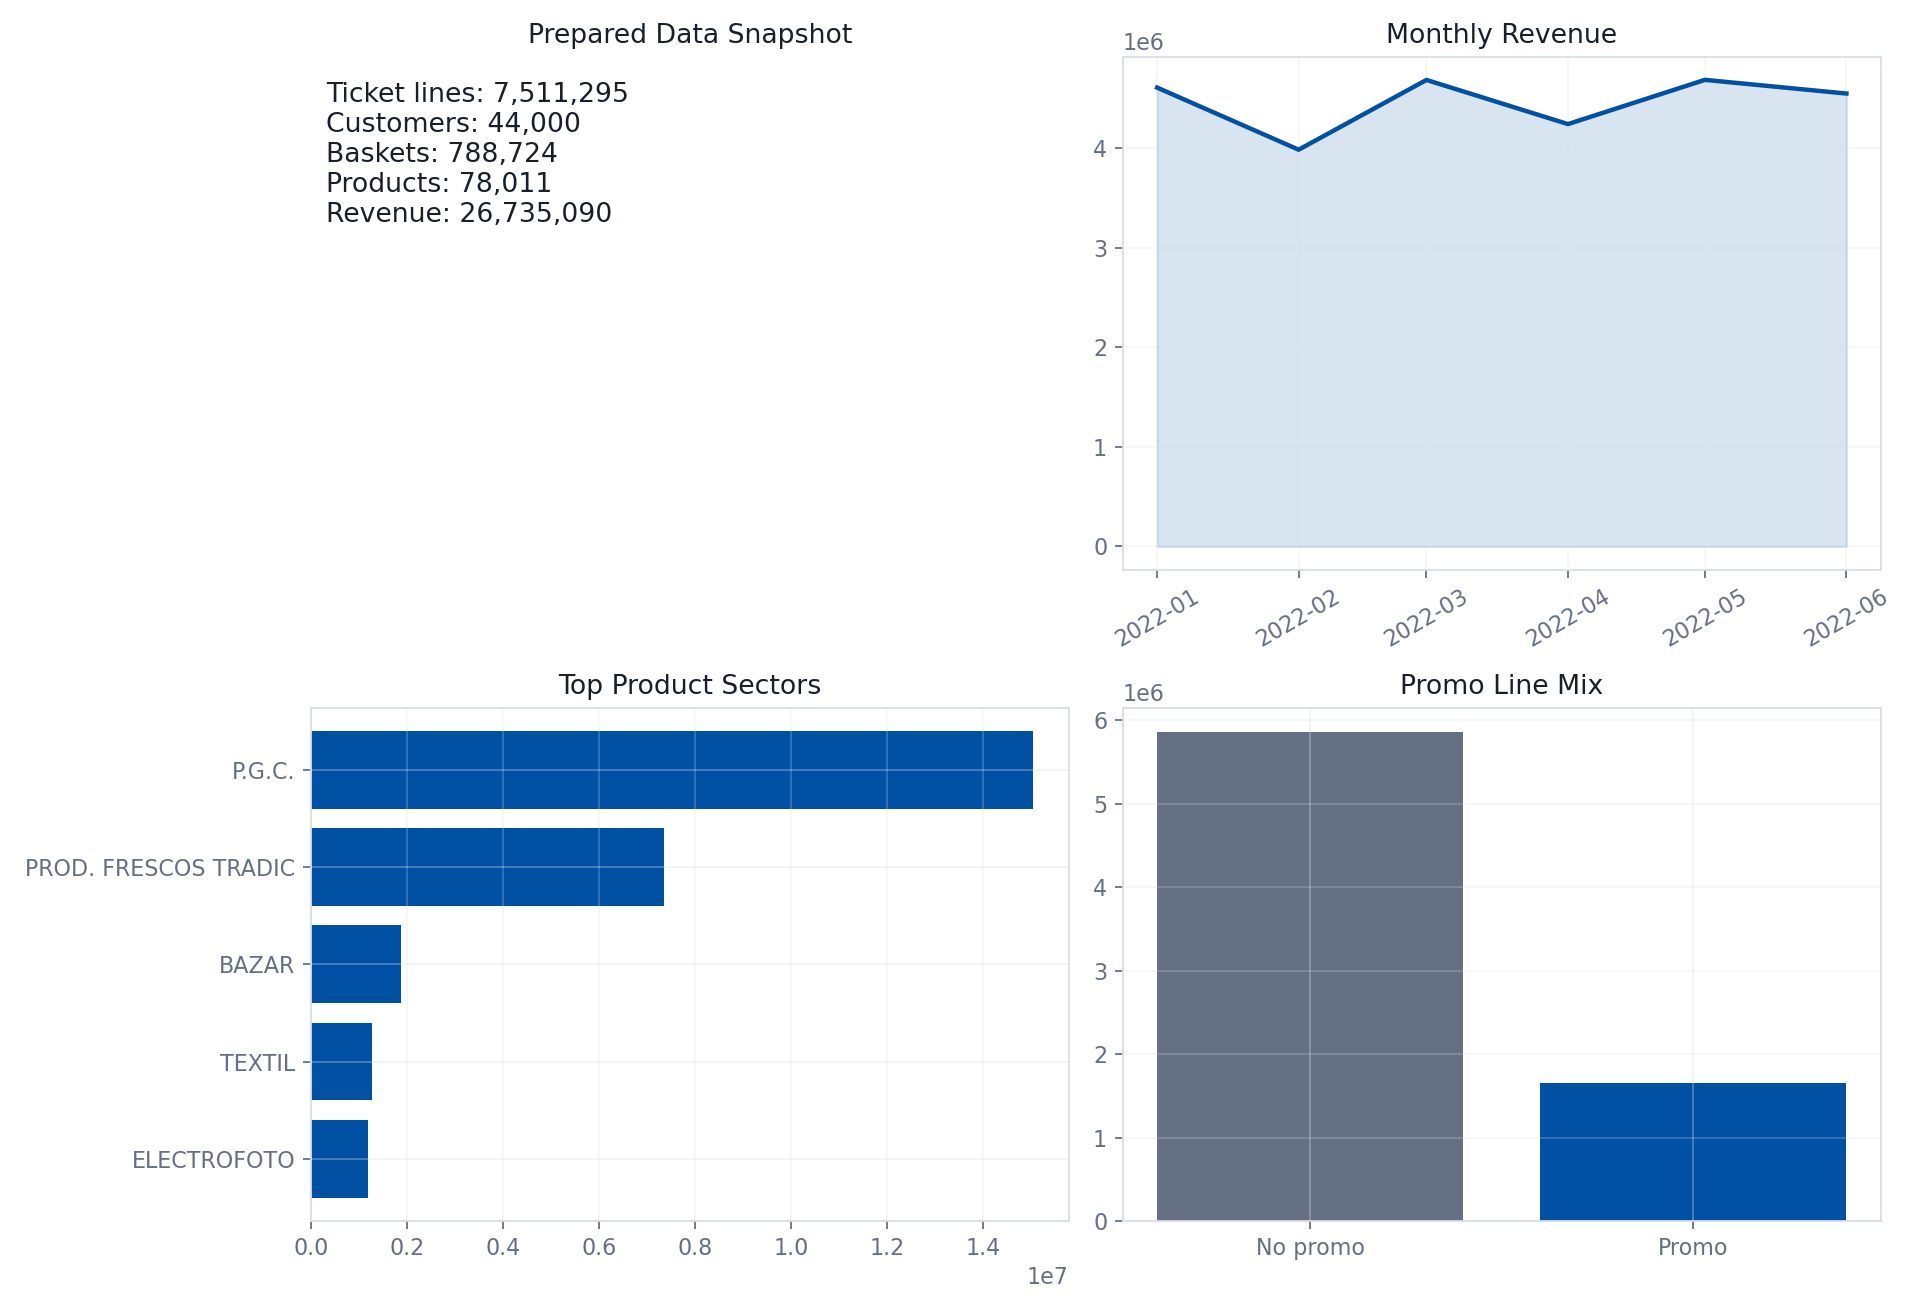

In [ ]:
import os
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

# Optional notebook override. Set to "dev" or "prod" to force a mode;
# leave as None to honor CARREFOUR_MODE, then the YAML default_mode.
NOTEBOOK_MODE_OVERRIDE = "dev"

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir():
        project_root = candidate
        break
else:
    project_root = Path.cwd().resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import configure_mode, load_config
from src.cache_audit import assert_mode_path_audit
from src.data_loader import load_prepared_transactions, peek
from src.stage_reports import display_stage_report, write_stage_report
from src.utils import set_global_seed

RUN_MODE = (NOTEBOOK_MODE_OVERRIDE or os.environ.get("CARREFOUR_MODE") or load_config().mode).strip().lower()
if RUN_MODE not in {"dev", "prod"}:
    raise ValueError(f"RUN_MODE must be 'dev' or 'prod', got {RUN_MODE!r}")
os.environ["CARREFOUR_MODE"] = RUN_MODE

previous_mode = globals().get("MODE")
CONFIG = configure_mode(RUN_MODE)
MODE = CONFIG.mode
DATA_PROCESSED = CONFIG.data_processed
MODELS = CONFIG.models
OUTPUTS = CONFIG.outputs

if previous_mode and previous_mode != MODE:
    for stale_name in [
        "transactions",
        "basket_path",
        "item2vec_model",
        "product_embeddings_path",
        "embedding_validation_csv",
        "embedding_validation_detail_md",
        "customer_embeddings_path",
        "behavior_path",
        "feature_sets",
        "model_suite",
        "stage6_diagnostics",
        "cluster_stability",
        "stability_table",
        "cluster_readiness_table",
        "stage6_winner_key",
        "stage6_stage1_assignment_path",
        "stage6_stage1_result_path",
        "stage6_stage1_candidate",
        "stage6_stage1_checks_path",
        "stage6_stage1_figure",
        "stage6_stage2_noise_feature_path",
        "stage6_stage2_noise_customers",
        "stage6_stage2_assignment_path",
        "stage6_stage2_result_path",
        "stage6_stage2_candidate",
        "stage6_stage2_checks_path",
        "stage6_stage2_figure",
        "stage6_lift_evidence_path",
        "stage6_lift_evidence",
        "stage6_4_projection_dir",
        "stage6_4_projection_figures",
        "stage6_6_projection_dir",
        "stage6_6_projection_figures",
        "stage6_6_winner_stability",
        "stage6_6_cluster_readiness",
        "stage6_6_cluster_readiness_figure",
        "profile_paths",
        "selected_key",
        "selection_evidence_path",
        "selected",
        "selected_assignment_path",
        "selected_profile_path",
        "stage7_artifacts_dir",
        "stage7_figures_dir",
        "stage7_quality",
        "stage7_readiness_path",
        "stage7_readiness",
        "stage7_ready_clusters",
        "stage7_review_clusters",
        "stage7_final_tribes",
        "stage7_review_candidates_path",
        "stage7_review_candidates",
        "product_summary_paths",
        "tribe_product_tables",
        "tribe_comparison_artifacts",
        "tribe_comparison",
        "customer_metric_tests_path",
        "customer_metric_tests",
        "stage7_significant_customer_metric_tests",
        "stage7_profile_overview",
        "stage7_profile_evidence",
        "stage7_noise_audit",
        "stage7_noise_audit_paths",
        "stage7_noise_summary_row",
        "stage7_storyline_paths",
        "stage7_storyline",
        "stage7_cluster_summary_paths",
        "tribe_vs_population_dashboard",
        "profile_comparison_heatmap",
        "stage7_theme_lift_heatmap",
        "stage7_lift_dir",
        "stage7_final_pack",
        "stage7_final_index",
        "stage7_card_paths",
        "stage7_card_count",
        "stage7_customer_metric_tests_path",
        "stage7_customer_metric_tests",
        "stage7_llm_evidence_path",
        "stage7_gemini_analysis",
        "stage7_gemini_analysis_path",
        "stage7_gemini_status",
        "stage7_gemini_reason",
        "top_lift_paths",
        "profile_export",
        "subsegment_opportunities",
        "subsegment_opportunities_path",
        "customer_subsegment_paths",
        "discovered_term_paths",
        "campaign_signal_paths",
        "profile_report_path",
        "clustering_atlas_paths",
        "llm_prompt_paths",
    ]:
        globals().pop(stale_name, None)

set_global_seed(CONFIG.random_seed)
CONFIG.ensure_directories()
mode_path_audit = assert_mode_path_audit(CONFIG)

transactions = load_prepared_transactions(cfg=CONFIG)
print(f"Run mode: {MODE}")
print(f"Data path: {DATA_PROCESSED}")
print(f"Model path: {MODELS}")
print(f"Output path: {OUTPUTS}")
peek(transactions, 3)

from src.visualization import plot_prepared_data_overview

stage0_figure = plot_prepared_data_overview(transactions, cfg=CONFIG)
stage0_report = write_stage_report(
    "00",
    "Load Prepared Data",
    summary=[
        f"Run mode active: {MODE}",
        "Mode/path audit passed; dev and prod namespaces are not mixed.",
        "Prepared transactions loaded from the configured mode path.",
    ],
    metrics={
        "mode_path_checks": mode_path_audit.height,
        "failed_mode_path_checks": mode_path_audit.filter(mode_path_audit.get_column("status") == "fail").height,
    },
    figures={"Prepared data overview": stage0_figure},
    artifacts={"Prepared transactions": CONFIG.prepared_transactions_path},
    cfg=CONFIG,
)
display_stage_report(stage0_report)
display(mode_path_audit.select(["check", "status", "exists", "reason"]).head(12))
display(Image(filename=str(stage0_figure)))

<a id="stage-0-5"></a>

## Stage 0.5: Expensive Cache Audit

Before running the expensive pipeline stages, this table checks whether Stage 1-6 artifacts will be reused from cache. A cache hit requires the artifact to exist and its metadata hash to match the current input files and config.

In [ ]:
import importlib
import os
import polars as pl

import src.utils
importlib.reload(src.utils)
import src.cache_audit
importlib.reload(src.cache_audit)
from src.cache_audit import stage_1_6_cache_audit
from src.stage_reports import display_stage_report, write_stage_report
# Optional: if existing artifacts were produced from the current data/config but metadata is missing,
# uncomment the next two lines once to adopt them into the cache manifest.
# from src.cache_audit import adopt_existing_stage_1_6_cache_metadata
# display(adopt_existing_stage_1_6_cache_metadata(CONFIG))


cache_audit = stage_1_6_cache_audit(CONFIG)
cache_misses = cache_audit.filter(~pl.col("cache_hit"))

stage0_5_report = write_stage_report(
    "00_5",
    "Expensive Cache Audit",
    summary=[
        "Checks whether expensive Stage 1-6 artifacts can be reused safely.",
        "Artifacts with cache_hit=False will be rebuilt when their stage runs.",
    ],
    metrics={
        "audited_artifacts": cache_audit.height,
        "cache_ready_artifacts": cache_audit.filter(pl.col("cache_hit")).height,
        "rebuild_artifacts": cache_misses.height,
    },
    artifacts={"Artifact metadata manifest": CONFIG.outputs / ".artifact_metadata.json"},
    cfg=CONFIG,
)
display_stage_report(stage0_5_report)
cache_display_cols = ["stage", "artifact", "cache_hit", "exists", "reason", "path"]
display(cache_audit.select([c for c in cache_display_cols if c in cache_audit.columns]).head(20))

if cache_misses.height:
    print("Artifacts listed as cache_hit=False will be rebuilt if their stage is run.")
else:
    print("All expensive Stage 1-6 artifacts are cache-ready.")


# Stage 0.5: Expensive Cache Audit

- Mode: `dev`

## Status
- Checks whether expensive Stage 1-6 artifacts can be reused safely.
- Artifacts with cache_hit=False will be rebuilt when their stage runs.

## Key Metrics

| Metric | Value |
|---|---|
| audited_artifacts | 11 |
| cache_ready_artifacts | 7 |
| rebuild_artifacts | 4 |

## Artifacts
- Artifact metadata manifest: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\.artifact_metadata.json`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

stage,artifact,cache_hit,exists,reason,path
str,str,bool,bool,str,str
"""1""","""basket_sentences""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""item2vec_model""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""product_embeddings""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""3""","""embedding_hubness_csv""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""3""","""embedding_validation_csv""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
…,…,…,…,…,…
"""5""","""behavioral_features""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""5""","""feature_set_embeddings_only""",false,true,"""metadata hash mismatch""","""C:\Users\rothl\Desktop\IE Caps…"
"""6""","""model_b_hdbscan_assignments""",false,false,"""artifact missing""","""C:\Users\rothl\Desktop\IE Caps…"


Artifacts listed as cache_hit=False will be rebuilt if their stage is run.


<a id="stage-1"></a>

## Stage 1: Basket Construction

Each ticket is treated as a basket sentence and each product id is a token. Products are not repeated by quantity unless `baskets.repeat_product_by_quantity` is enabled in the config.

[13:15:18] Stage 1 baskets: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\embeddings\basket_sentences.parquet


[13:15:19] Stage 1 figures: wrote basket summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage1_basket_sentence_lengths.png
[13:15:19] Stage 1 baskets: staple diagnostics cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage1
[13:15:20] Stage 1 figures: wrote common-product diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage1_common_product_diagnostics.png


# Stage 01: Basket Sentences and Common-Product Exposure

- Mode: `dev`

## Status
- Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.
- Common-product exposure and downsampling retention are audited before Item2Vec training.

## Key Metrics

| Metric | Value |
|---|---|
| n_baskets | 788443 |
| avg_products_per_basket | 7.367 |
| median_products_per_basket | 4 |
| max_products_per_basket | 159 |
| common_product_candidates | 2102 |
| common_product_preview_rows | 50 |
| basket_retention_pct | 99.964 |
| unique_pair_retention_pct | 77.33 |
| fallback_basket_pct | 3.2 |
| auto_excluded_products | 1 |
| downsampled_common_candidate_products | 2101 |

## Visual Evidence
- Basket token summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage1_basket_sentence_lengths.png`
- Common-product exposure: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage1_common_product_diagnostics.png`

## Artifacts
- Basket sentences: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\embeddings\basket_sentences.parquet`
- Common-product candidates CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage1\common_product_candidates.csv`
- Product ubiquity diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage1\product_ubiquity_diagnostics.parquet`
- Downsampling plan: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage1\common_product_downsampling_plan.parquet`
- Downsampling summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage1\basket_downsampling_summary.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

n_baskets,avg_products_per_basket,median_products_per_basket,max_products_per_basket
u32,f64,f64,u32
788443,7.367003,4.0,159


raw_baskets,raw_unique_ticket_product_pairs,raw_common_candidate_pairs,excluded_pairs,manual_excluded_pairs,auto_excluded_pairs,candidate_baskets_after_exclusions,candidate_pairs_after_exclusions,sample_selected_pairs,sample_dropped_common_candidate_pairs,fallback_baskets,plan_products,common_candidate_products,excluded_products,manual_excluded_products,auto_excluded_products,downsampled_common_candidate_products,mean_keep_probability,mean_common_candidate_keep_probability,output_baskets,output_unique_ticket_product_pairs,baskets_dropped_by_downsampling,basket_retention_pct,unique_pair_retention_pct,unique_pairs_dropped_by_downsampling,fallback_basket_pct,sample_modulus
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64,f64,f64,i64,f64,i64
788724,7511295,3970300,159109,0,159109,788443,7352186,5783222,1568964,25240,78011,2102,1,0,1,2101,0.993278,0.750517,788443,5808462,281,99.964373,77.329701,1702833,3.200105,1000000


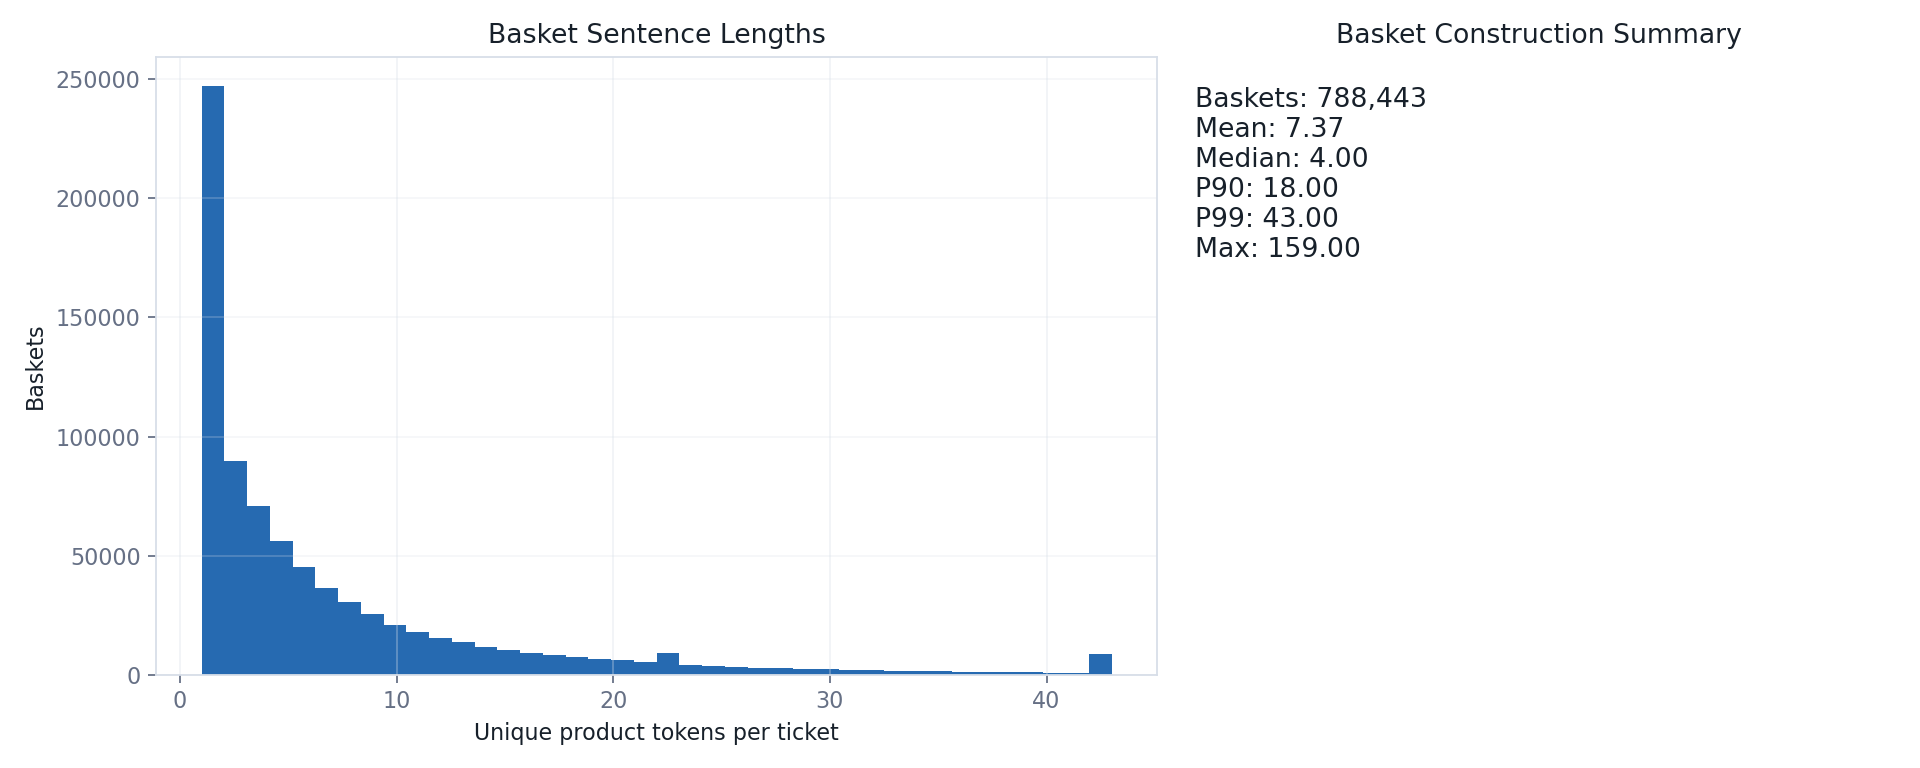

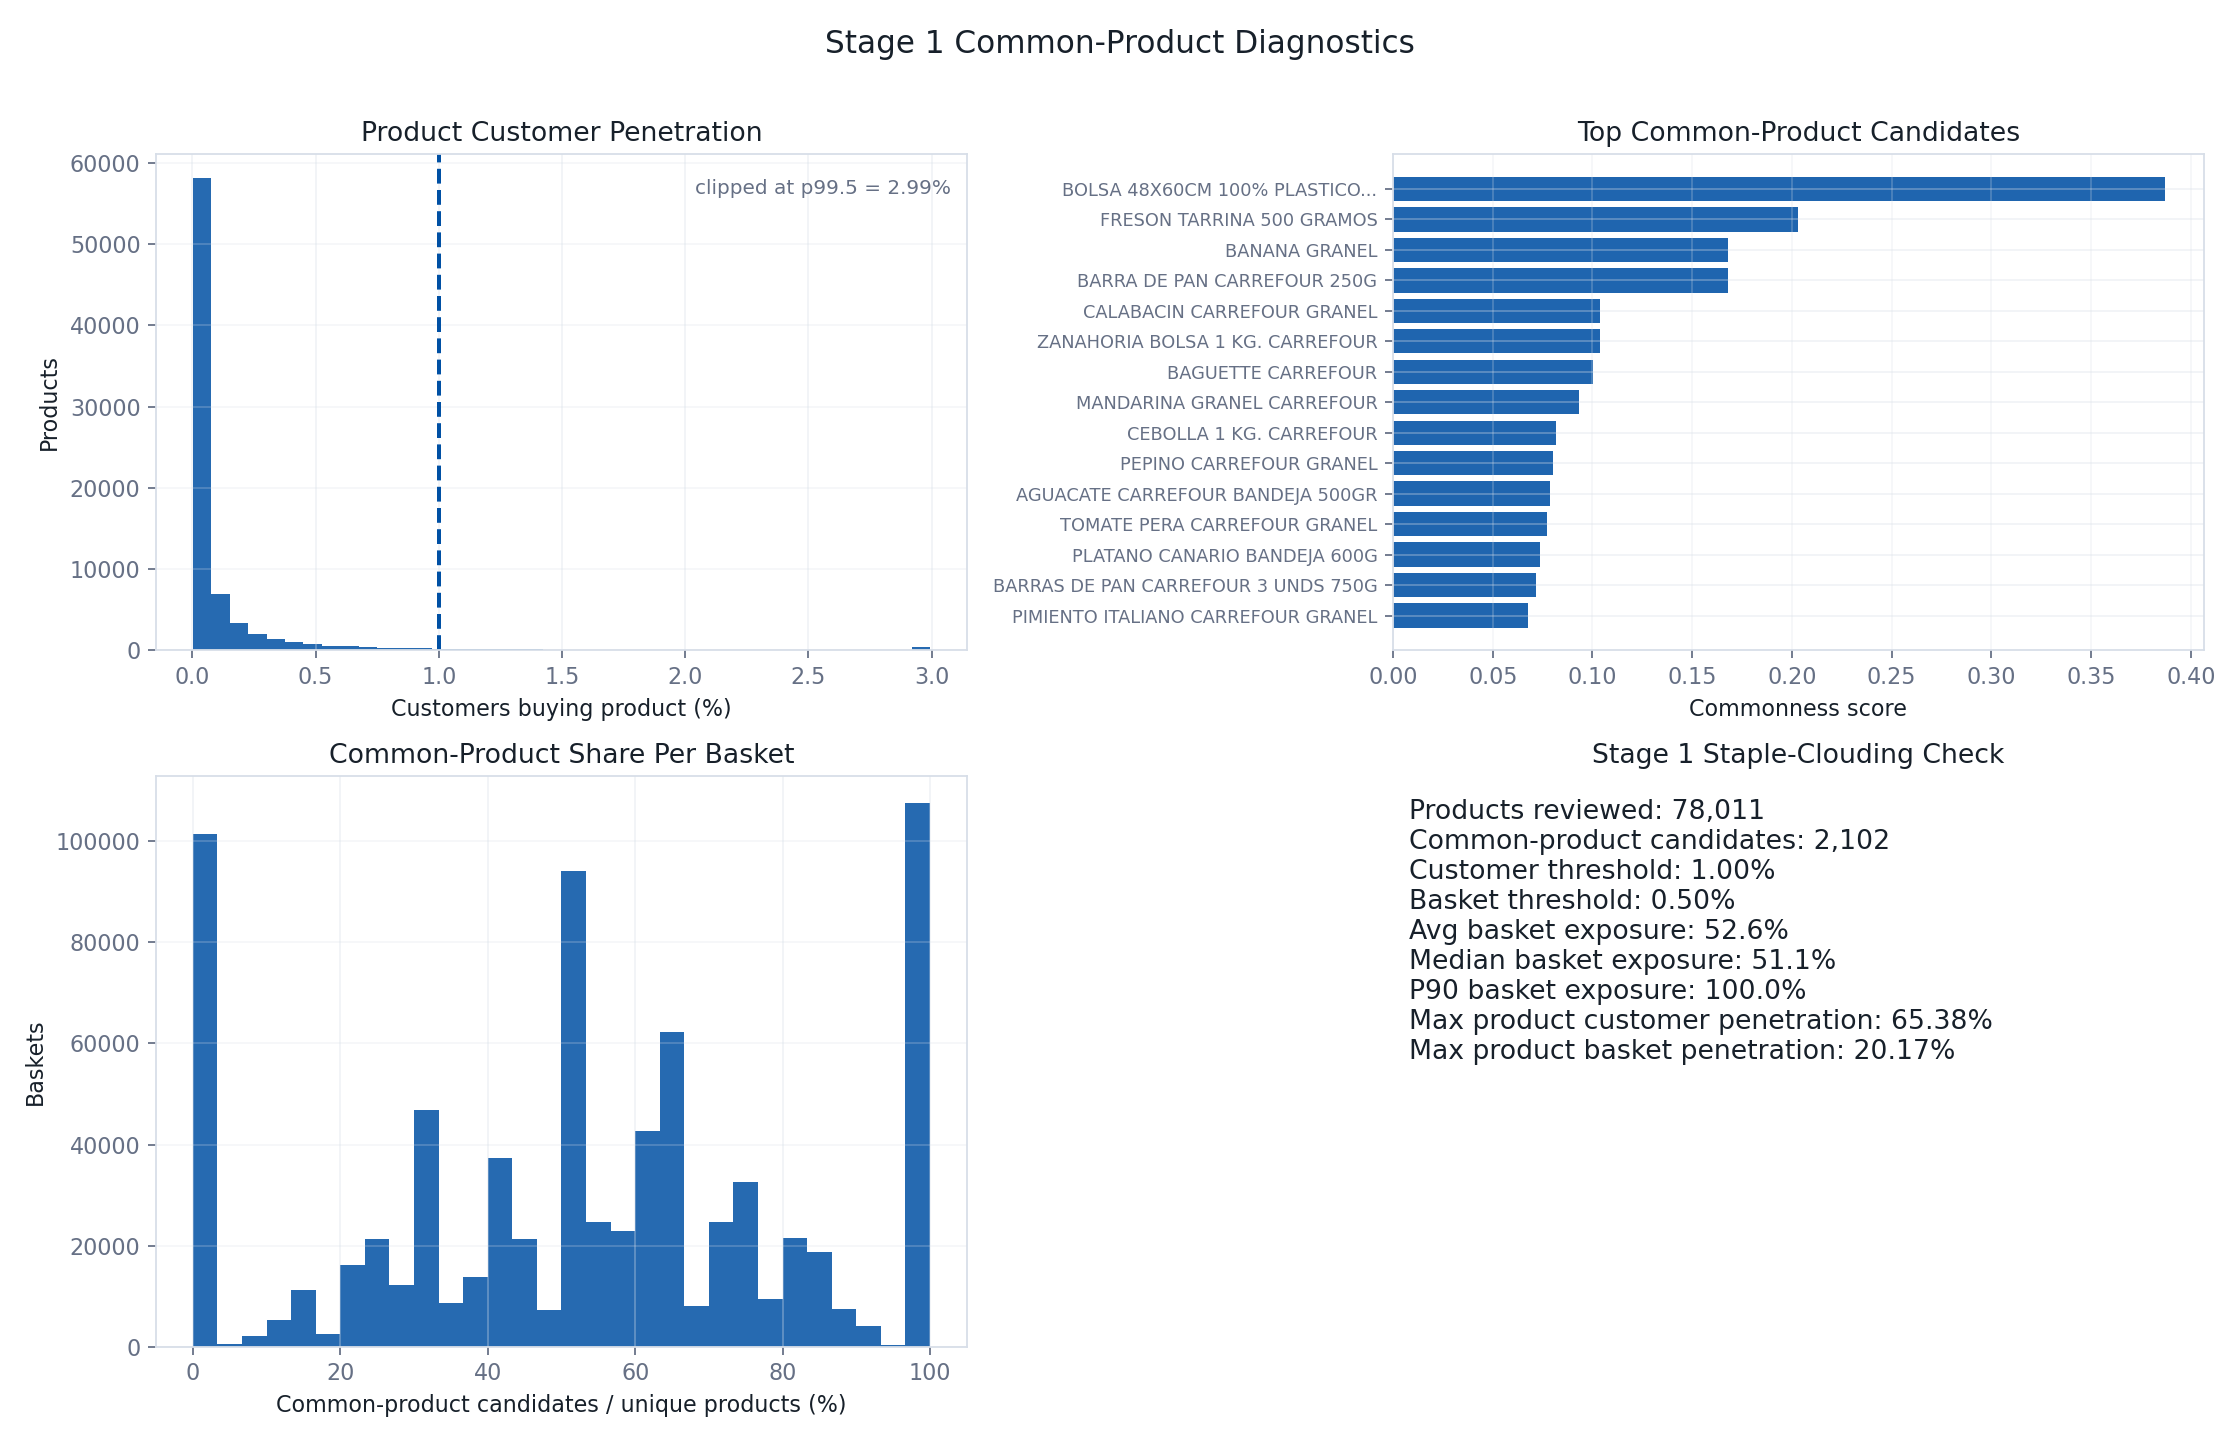

Stage 2 Item2Vec basket path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\embeddings\basket_sentences.parquet


In [ ]:
from IPython.display import Image, display
import polars as pl

from src.basket_builder import (
    basket_summary,
    build_basket_sentences,
    build_basket_staple_diagnostics,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_basket_staple_diagnostics,
    plot_basket_summary,
)

basket_path = build_basket_sentences(transactions=transactions, cfg=CONFIG)
stage1_basket_summary = basket_summary(basket_path)
stage1_figure = plot_basket_summary(basket_path, cfg=CONFIG)

stage1_diagnostics = build_basket_staple_diagnostics(transactions=transactions, cfg=CONFIG)
stage1_staple_figure = plot_basket_staple_diagnostics(
    stage1_diagnostics["product_diagnostics"],
    stage1_diagnostics["basket_exposure"],
    cfg=CONFIG,
)
stage1_product_diagnostics = pl.scan_parquet(stage1_diagnostics["product_diagnostics"])
stage1_common_products = stage1_product_diagnostics.filter(pl.col("common_product_candidate")).select(pl.len()).collect()[0, 0]
stage1_common_preview_rows = (
    pl.read_csv(stage1_diagnostics["common_products_csv"]).height
    if stage1_diagnostics["common_products_csv"].exists()
    else 0
)
stage1_downsampling_diag_cfg = CONFIG.get("baskets.diagnostics", {}) or {}
stage1_downsampling_plan_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_plan_output", "common_product_downsampling_plan.parquet"))
stage1_downsampling_summary_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_summary_output", "basket_downsampling_summary.csv"))
stage1_metrics = stage1_basket_summary.row(0, named=True)
stage1_metrics["common_product_candidates"] = stage1_common_products
stage1_metrics["common_product_preview_rows"] = stage1_common_preview_rows
stage1_downsampling_summary = None
if stage1_downsampling_summary_path.exists():
    stage1_downsampling_summary = pl.read_csv(stage1_downsampling_summary_path)
    stage1_metrics.update(
        stage1_downsampling_summary.select(
            [
                "basket_retention_pct",
                "unique_pair_retention_pct",
                "fallback_basket_pct",
                "auto_excluded_products",
                "downsampled_common_candidate_products",
            ]
        ).row(0, named=True)
    )
stage1_report = write_stage_report(
    "01",
    "Basket Sentences and Common-Product Exposure",
    summary=[
        "Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.",
        "Common-product exposure and downsampling retention are audited before Item2Vec training.",
    ],
    metrics=stage1_metrics,
    figures={
        "Basket token summary": stage1_figure,
        "Common-product exposure": stage1_staple_figure,
    },
    artifacts={
        "Basket sentences": basket_path,
        "Common-product candidates CSV": stage1_diagnostics["common_products_csv"],
        "Product ubiquity diagnostics": stage1_diagnostics["product_diagnostics"],
        "Downsampling plan": stage1_downsampling_plan_path if stage1_downsampling_plan_path.exists() else None,
        "Downsampling summary": stage1_downsampling_summary_path if stage1_downsampling_summary_path.exists() else None,
    },
    cfg=CONFIG,
)
display_stage_report(stage1_report)
display(stage1_basket_summary)
if stage1_downsampling_summary is not None:
    display(stage1_downsampling_summary)
display(Image(filename=str(stage1_figure)))
display(Image(filename=str(stage1_staple_figure)))
print(f"Stage 2 Item2Vec basket path: {basket_path}")


<a id="stage-2"></a>

## Stage 2: Item2Vec Product Embeddings

The Word2Vec model learns product proximity from basket co-occurrence. These product embeddings are the core signal used to represent customers.

The training function prints the active hyperparameters and one progress line per epoch. If a cached model already exists, it prints the cache details instead; pass `force=True` to retrain.

Item2Vec: loading cached model
  baskets: 788,443
  product tokens: 5,808,462; avg/basket: 7.37; median/basket: 4.00
  training baskets: 649,545; training tokens: 4,988,135; skipped short baskets: 138,898; capped baskets: 59,067
  model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\word2vec_product.model
  config: vector_size=128, window=20 (configured=2, full_basket_context=True), min_tokens_per_basket=2, max_tokens_per_basket=20, min_count=60, negative=10, sample=0.0001, epochs=5, sg=1, workers=5, seed=42


Item2Vec cache loaded: vocab=14,937, vector_size=128
[13:15:20] Stage 2 product embeddings: wrote training corpus diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage2\item2vec_training_corpus_diagnostics.csv
[13:15:20] Stage 2 product embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\embeddings\product_embeddings.parquet
[13:15:21] Stage 2 figures: wrote product embedding diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage2_product_embedding_diagnostics.png


# Stage 02: Product Embedding Training

- Mode: `dev`

## Status
- Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.
- Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active conf...

## Key Metrics

| Metric | Value |
|---|---|
| embedded_products | 14937 |
| embedding_dimensions | 128 |
| word2vec_window | 2 |
| word2vec_min_count | 60 |
| baskets | 788443 |
| training_baskets | 649545 |
| skipped_short_basket_pct | 17.617 |
| capped_basket_pct | 7.492 |
| training_token_retention_pct | 85.877 |
| effective_window | 20 |

## Visual Evidence
- Product embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage2_product_embedding_diagnostics.png`

## Artifacts
- Product embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\embeddings\product_embeddings.parquet`
- Training corpus diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage2\item2vec_training_corpus_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

baskets,product_tokens,avg_tokens_per_basket,median_tokens_per_basket,max_tokens_per_basket,training_baskets,skipped_short_baskets,capped_baskets,training_product_tokens,training_basket_pct,skipped_short_basket_pct,capped_basket_pct,training_token_retention_pct,configured_window,effective_window,full_basket_context,min_tokens_per_basket,min_count,sample,negative,epochs,sg
i64,i64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,bool,i64,i64,f64,i64,i64,i64
788443,5808462,7.367003,4.0,20,649545,138898,59067,4988135,82.383254,17.616746,7.491601,85.877036,2,20,true,2,60,0.0001,10,5,1


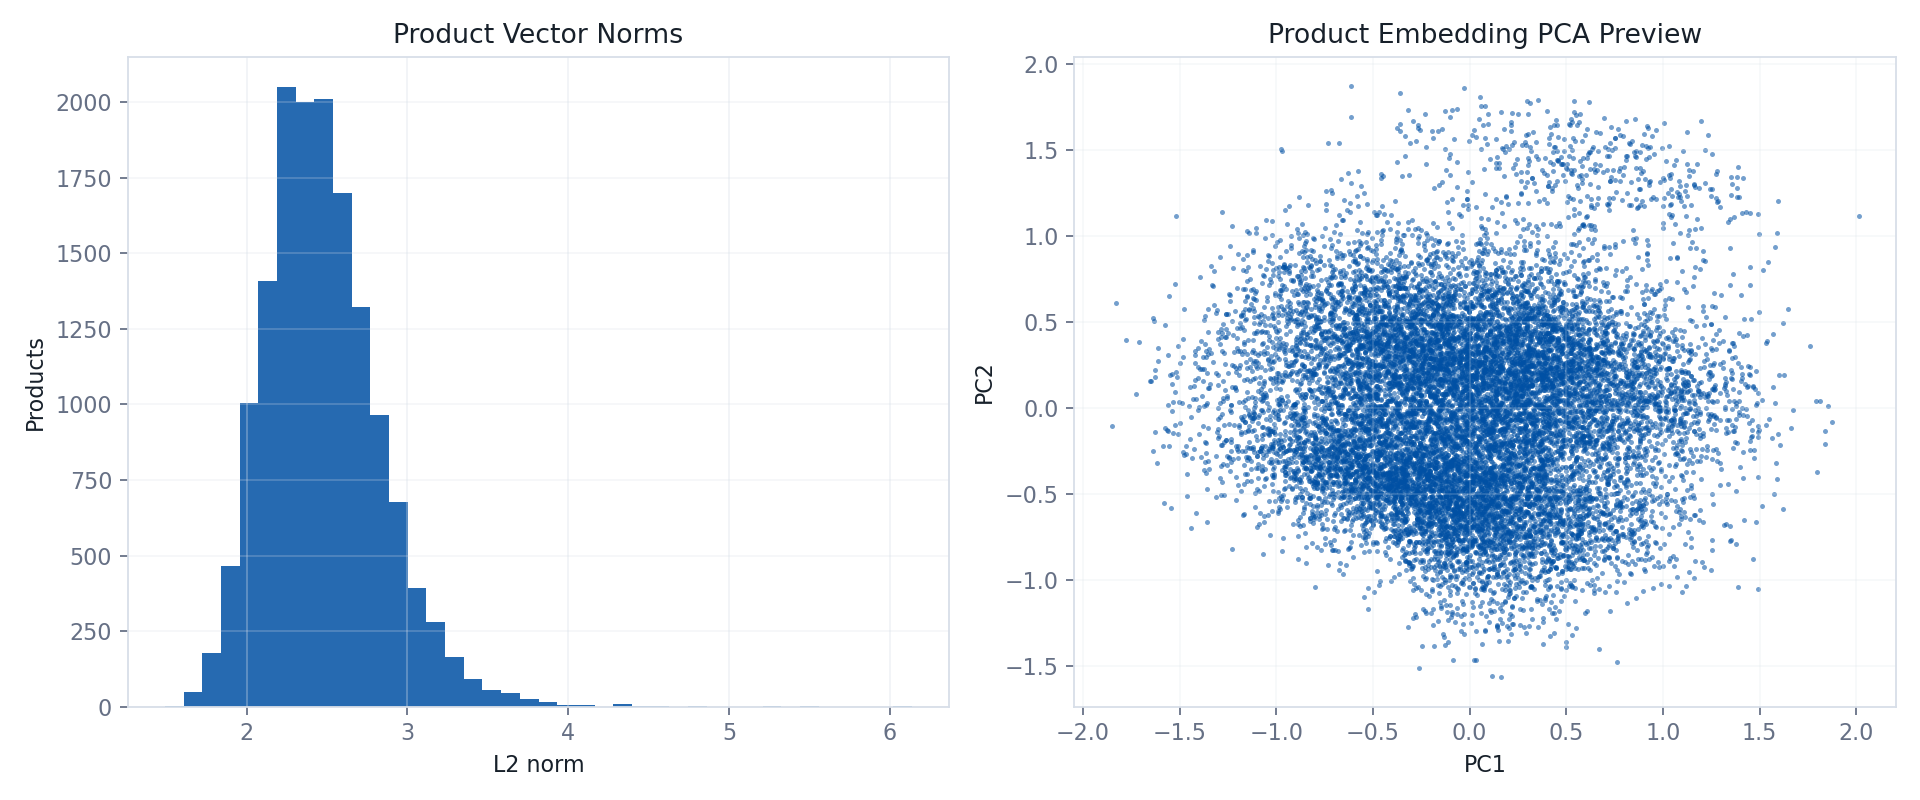

In [ ]:
from IPython.display import Image
import polars as pl

from src.item2vec import save_product_embeddings, train_item2vec, write_item2vec_training_diagnostics
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_product_embedding_diagnostics

item2vec_model = train_item2vec(basket_path, cfg=CONFIG, verbose=True)
stage2_training_diagnostics_path = write_item2vec_training_diagnostics(basket_path, cfg=CONFIG)
stage2_training_diagnostics = pl.read_csv(stage2_training_diagnostics_path)
product_embeddings_path = save_product_embeddings(item2vec_model, cfg=CONFIG)
stage2_figure = plot_product_embedding_diagnostics(product_embeddings_path, cfg=CONFIG)
stage2_schema = pl.read_parquet(product_embeddings_path, n_rows=1).columns
stage2_metrics = {
    "embedded_products": pl.scan_parquet(product_embeddings_path).select(pl.len()).collect()[0, 0],
    "embedding_dimensions": len([c for c in stage2_schema if c.startswith("emb_")]),
    "word2vec_window": CONFIG.get("word2vec.window"),
    "word2vec_min_count": CONFIG.get("word2vec.min_count"),
}
stage2_metrics.update(
    stage2_training_diagnostics.select(
        [
            "baskets",
            "training_baskets",
            "skipped_short_basket_pct",
            "capped_basket_pct",
            "training_token_retention_pct",
            "effective_window",
        ]
    ).row(0, named=True)
)
stage2_report = write_stage_report(
    "02",
    "Product Embedding Training",
    summary=[
        "Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.",
        "Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active config.",
    ],
    metrics=stage2_metrics,
    figures={"Product embedding diagnostics": stage2_figure},
    artifacts={"Product embeddings": product_embeddings_path, "Training corpus diagnostics": stage2_training_diagnostics_path},
    cfg=CONFIG,
)
display_stage_report(stage2_report)
display(stage2_training_diagnostics)
display(Image(filename=str(stage2_figure)))


<a id="stage-3"></a>

## Stage 3: Product Embedding Validation

Before clustering customers, the nearest-neighbor report checks whether embeddings capture meaningful substitutes, complements, or shared basket missions.

[13:15:22] Stage 3 embedding validation: cache hit | csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage3\embedding_validation.csv, hubness=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage3\embedding_hubness.csv
[13:15:22] Stage 3 figures: wrote embedding validation summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage3_embedding_validation_summary.png


# Stage 03: Product Embedding Validation

- Mode: `dev`

## Status
- Guardrail status: action_needed
- Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.
- Issues: Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 98.2%...

## Key Metrics

| Metric | Value |
|---|---|
| validated_products | 1552 |
| guardrail_issue_count | 2 |

## Visual Evidence
- Embedding validation summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage3_embedding_validation_summary.png`

## Artifacts
- Validation CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage3\embedding_validation.csv`
- Hubness CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage3\embedding_hubness.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

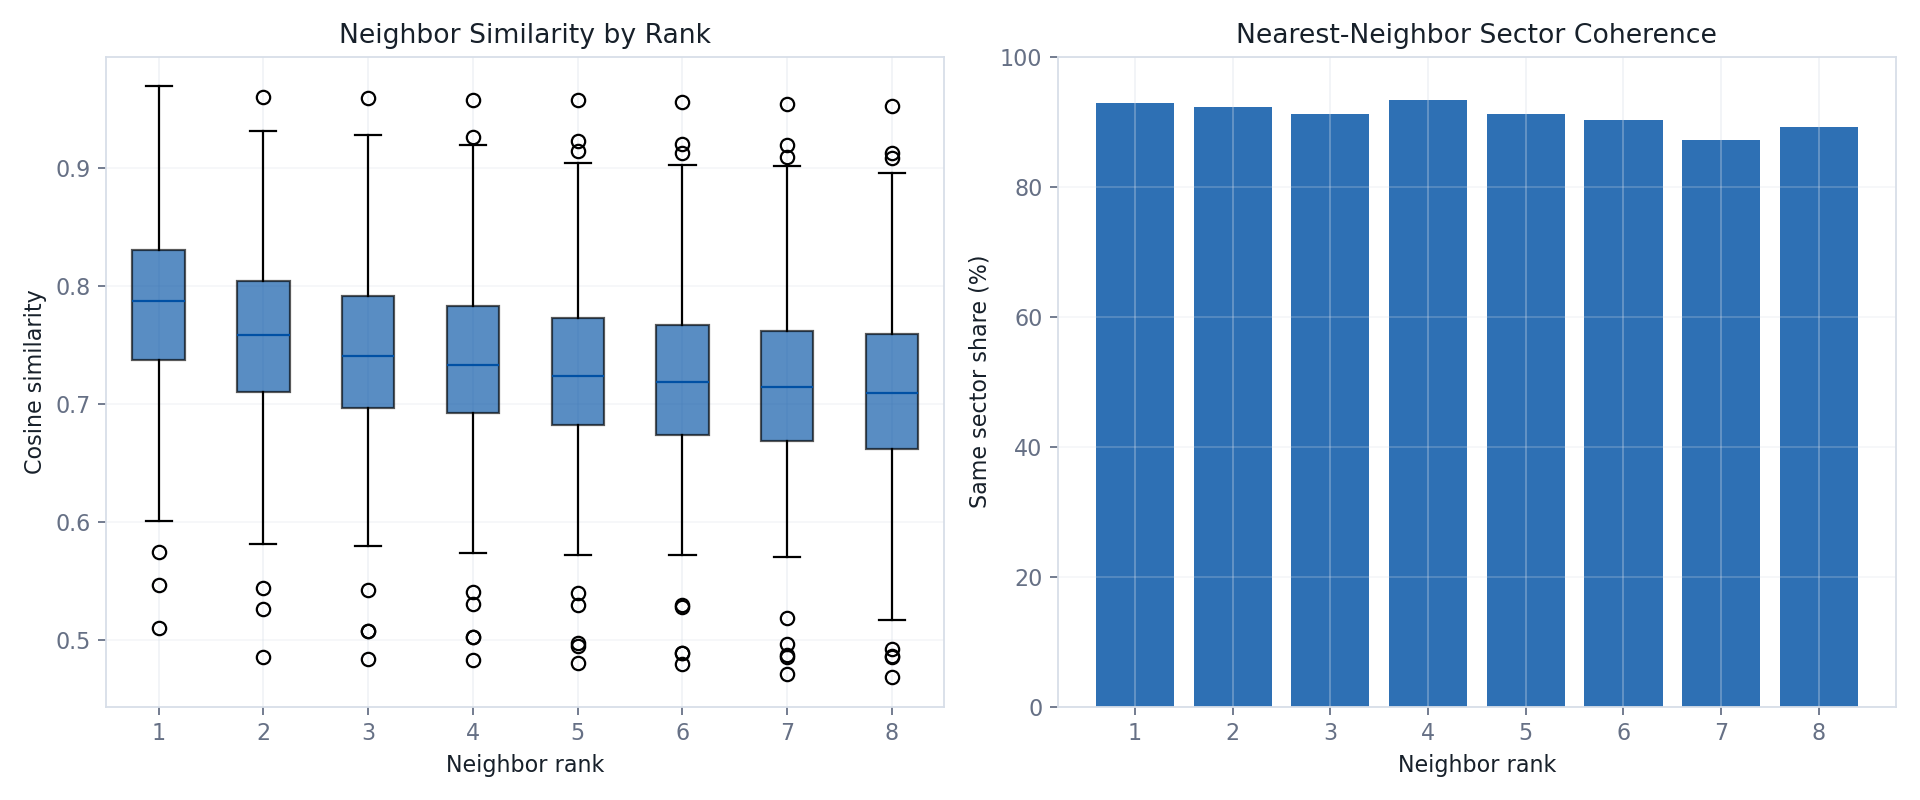

{'status': 'action_needed',
 'summary': 'Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.',
 'issues': ['Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 98.2%).',
  'Top hubness lift is high (11.30).'],
 'upstream_actions': ['Inspect the top hubness rows. If the hubs are sparse non-staples, raise `word2vec.min_count`; if they are true common staples, tune Stage 1 common-product exposure; if they are coherent products split by Carrefour sector taxonomy, keep as a watch item.',
  'Reduce broad co-occurrence blur upstream and rerun Stage 3; high hubness usually means a few products are absorbing too much neighborhood mass.'],
 'metrics': {'common_same_sector_share': 0.925,
  'rare_same_sector_share': 0.8125,
  'common_rare_same_sector_gap': 0.11250000000000004,
  'generic_neighbor_warning_product_share': 0.0,
  'max_hub_cross_sector_share': 0.9818181818181818,
  'max_hubness_lift': 

In [ ]:
from IPython.display import Image
import polars as pl

from src.embedding_validation import product_embedding_guardrail_status, validate_product_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_embedding_validation_quality_extracts, plot_embedding_validation_summary

embedding_validation_csv, embedding_validation_detail_md = validate_product_embeddings(
    product_embeddings_path,
    transactions=transactions,
    cfg=CONFIG,
)
stage3_figure = plot_embedding_validation_summary(embedding_validation_csv, cfg=CONFIG)
stage3_extract_figures = {}
if CONFIG.get("embedding_validation.write_extract_figures", False):
    stage3_extract_figures = plot_embedding_validation_quality_extracts(embedding_validation_csv, cfg=CONFIG)
stage3_guardrail_status = product_embedding_guardrail_status(embedding_validation_csv, cfg=CONFIG)
stage3_figures = {"Embedding validation summary": stage3_figure}
stage3_figures.update({f"Quality extract: {name}": path for name, path in stage3_extract_figures.items()})
stage3_issues = stage3_guardrail_status["issues"] or ["None"]
stage3_report = write_stage_report(
    "03",
    "Product Embedding Validation",
    summary=[
        f"Guardrail status: {stage3_guardrail_status['status']}",
        stage3_guardrail_status["summary"],
        "Issues: " + "; ".join(stage3_issues[:4]),
    ],
    metrics={
        "validated_products": pl.read_csv(embedding_validation_csv).height,
        "guardrail_issue_count": 0 if stage3_guardrail_status["issues"] is None else len(stage3_guardrail_status["issues"]),
    },
    figures=stage3_figures,
    artifacts={
        "Validation CSV": embedding_validation_csv,
        "Hubness CSV": stage3_guardrail_status["hubness_csv"],
    },
    cfg=CONFIG,
)
display_stage_report(stage3_report)
display(Image(filename=str(stage3_figure)))
for figure_path in stage3_extract_figures.values():
    display(Image(filename=str(figure_path)))
stage3_guardrail_status


<a id="stage-4"></a>

## Stage 4: Customer Embeddings

Customer vectors are weighted means of product embeddings. The official weighting starts from product quantities (`unidades`), applies the configured product-purchase recency decay and repeated-basket frequency scaling, then aggregates product vectors. This keeps clustering driven by purchased products, purchase intensity, recency, and repeat behavior rather than spend. IDF-downweighted variants remain sandbox-only unless promoted into the official YAML recipe after evidence review.

[13:15:22] Stage 4 customer embeddings: pre-aggregating transaction weights by customer-product | quantity_transform=log1p, recency_weighting=True, frequency_weighting=True
[13:15:22] Stage 4 customer embeddings: applying product IDF weights to customer-product rows
[13:15:40] Stage 4 customer embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\customer_embeddings.parquet
[13:15:41] Stage 4 figures: wrote customer embedding diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage4_customer_embedding_diagnostics.png


# Stage 04: Customer Embeddings Coverage and Dominance Gates

- Mode: `dev`

## Status
- Customer vectors are weighted aggregations of purchased-product embeddings.
- Coverage gates check how much transaction signal survives product embedding coverage.
- Dominance gates check whether common products overwhelm customer vectors.

## Key Metrics

| Metric | Value |
|---|---|
| embedded_customers | 43963 |
| weight_strategy | quantity_idf |
| quantity_transform | log1p |
| common_product_weight_share_pct | 43.595 |
| mean_customer_common_product_weight_share_pct | 40.763 |
| p95_customer_common_product_weight_share_pct | 69.119 |
| top_product_weight_share_pct | 0.7704 |
| top_10_product_weight_share_pct | 2.771 |
| mean_customer_top_product_weight_share_pct | 10.484 |
| stage4_gate_status | pass |
| stage4_gate_issues | None |
| recency_weighting_enabled | True |
| recency_reference_date | 2022-06-30 |
| recency_half_life_days | 180 |
| mean_recency_multiplier | 0.7224 |
| frequency_weighting_enabled | True |
| frequency_transform | log1p |
| mean_frequency_multiplier | 1.091 |
| p95_customer_product_basket_count | 4 |
| line_coverage_pct | 87.695 |
| unit_coverage_pct | 89.49 |
| product_coverage_pct | 19.147 |
| customer_coverage_pct | 99.916 |
| zero_embedded_customer_pct | 0.0841 |

## Visual Evidence
- Customer embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage4_customer_embedding_diagnostics.png`

## Artifacts
- Customer embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\customer_embeddings.parquet`
- Weight diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage4\customer_embedding_weight_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

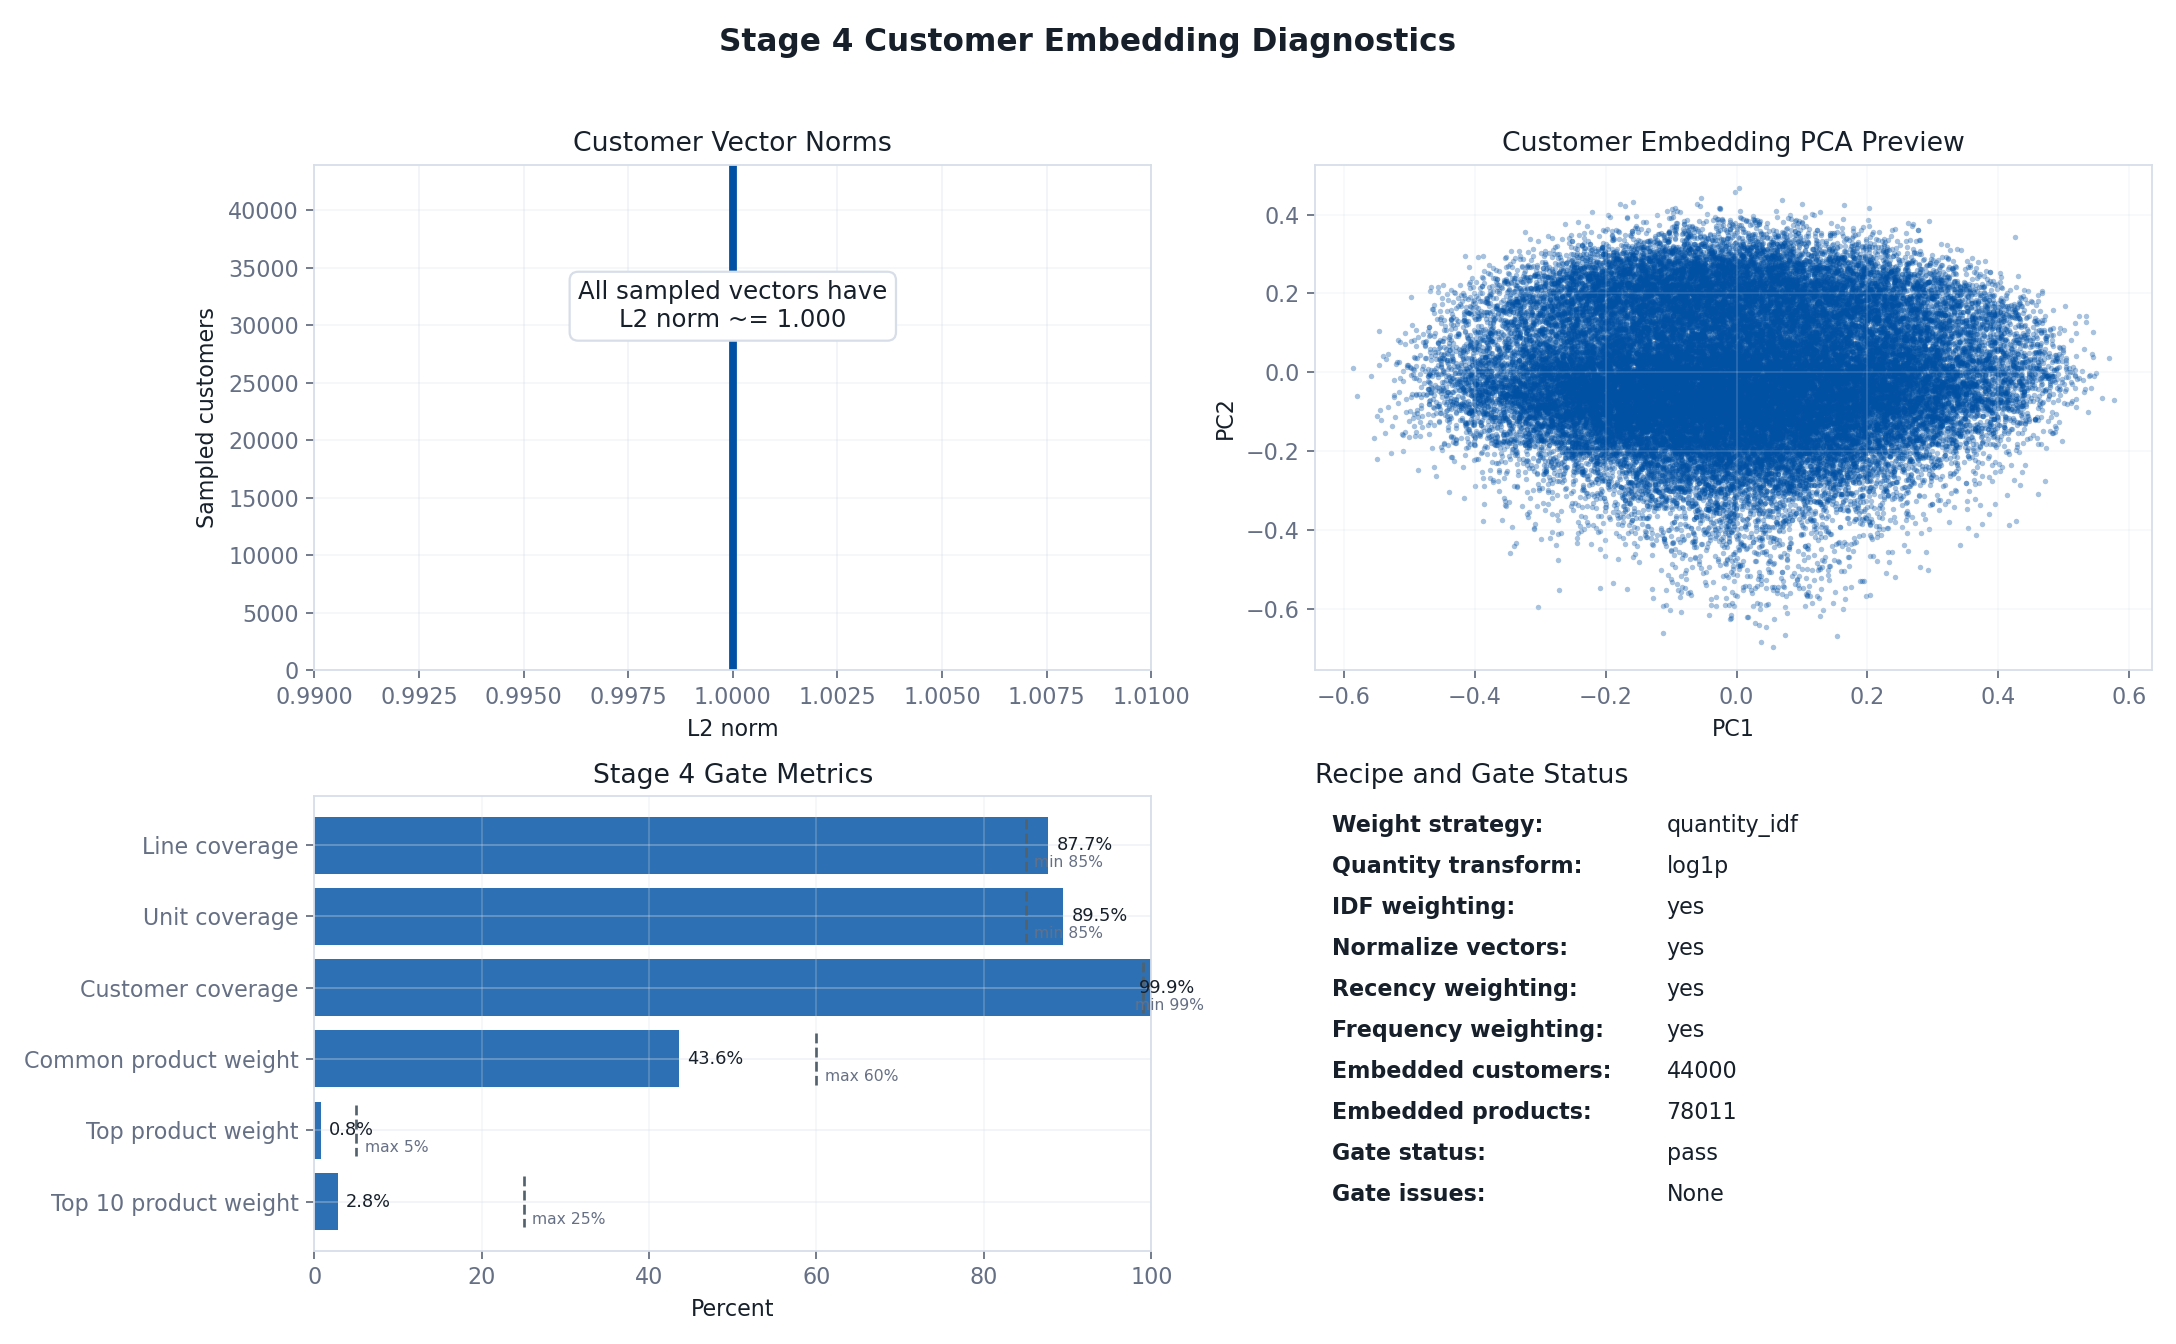

weight_strategy,quantity_transform,common_product_weight_share_pct,mean_customer_common_product_weight_share_pct,p95_customer_common_product_weight_share_pct,top_product_weight_share_pct,top_10_product_weight_share_pct,mean_customer_top_product_weight_share_pct,stage4_gate_status,stage4_gate_issues,recency_weighting_enabled,recency_reference_date,recency_half_life_days,mean_recency_multiplier,frequency_weighting_enabled,frequency_transform,mean_frequency_multiplier,p95_customer_product_basket_count,line_coverage_pct,unit_coverage_pct,product_coverage_pct,customer_coverage_pct,zero_embedded_customer_pct
str,str,f64,f64,f64,f64,f64,f64,str,str,bool,str,f64,f64,bool,str,f64,f64,f64,f64,f64,f64,f64
"""quantity_idf""","""log1p""",43.594959,40.763054,69.119443,0.770365,2.770672,10.483853,"""pass""","""None""",true,"""2022-06-30""",180.0,0.722394,true,"""log1p""",1.091318,4.0,87.694852,89.489724,19.1473,99.915909,0.084091


In [ ]:
from IPython.display import Image, display
import polars as pl

from src.customer_embeddings import build_customer_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_customer_embedding_diagnostics

customer_embeddings_path = build_customer_embeddings(
    product_embeddings_path,
    transactions=transactions,
    normalize_vectors=CONFIG.get("customer_embeddings.normalize_vectors", False),
    cfg=CONFIG,
)
stage4_figure = plot_customer_embedding_diagnostics(customer_embeddings_path, cfg=CONFIG)

stage4_diag_cfg = CONFIG.get("customer_embeddings.diagnostics", {}) or {}
stage4_weight_summary_path = (
    CONFIG.artifacts
    / str(stage4_diag_cfg.get("output_dir", "stage4"))
    / f"{stage4_diag_cfg.get('output_prefix', 'customer_embedding')}_weight_diagnostics.csv"
)
stage4_display_cols = [
    "weight_strategy",
    "quantity_transform",
    "common_product_weight_share_pct",
    "mean_customer_common_product_weight_share_pct",
    "p95_customer_common_product_weight_share_pct",
    "top_product_weight_share_pct",
    "top_10_product_weight_share_pct",
    "mean_customer_top_product_weight_share_pct",
    "stage4_gate_status",
    "stage4_gate_issues",
    "recency_weighting_enabled",
    "recency_reference_date",
    "recency_half_life_days",
    "mean_recency_multiplier",
    "frequency_weighting_enabled",
    "frequency_transform",
    "mean_frequency_multiplier",
    "p95_customer_product_basket_count",
    "line_coverage_pct",
    "unit_coverage_pct",
    "product_coverage_pct",
    "customer_coverage_pct",
    "zero_embedded_customer_pct",
]
stage4_weight_summary = None
stage4_report_metrics = {
    "embedded_customers": pl.scan_parquet(customer_embeddings_path).select(pl.len()).collect()[0, 0]
}
if stage4_weight_summary_path.exists():
    stage4_weight_summary = pl.read_csv(stage4_weight_summary_path)
    available_stage4_cols = [c for c in stage4_display_cols if c in stage4_weight_summary.columns]
    if available_stage4_cols:
        stage4_report_metrics.update(stage4_weight_summary.select(available_stage4_cols).row(0, named=True))
stage4_report = write_stage_report(
    "04",
    "Customer Embeddings Coverage and Dominance Gates",
    summary=[
        "Customer vectors are weighted aggregations of purchased-product embeddings.",
        "Coverage gates check how much transaction signal survives product embedding coverage.",
        "Dominance gates check whether common products overwhelm customer vectors.",
    ],
    metrics=stage4_report_metrics,
    figures={"Customer embedding diagnostics": stage4_figure},
    artifacts={
        "Customer embeddings": customer_embeddings_path,
        "Weight diagnostics": stage4_weight_summary_path if stage4_weight_summary_path.exists() else None,
    },
    cfg=CONFIG,
    max_metric_rows=32,
)
display_stage_report(stage4_report)
display(Image(filename=str(stage4_figure)))
if stage4_weight_summary is not None:
    display(stage4_weight_summary.select([c for c in stage4_display_cols if c in stage4_weight_summary.columns]))


<a id="stage-5"></a>

## Stage 5: Official Feature Set

Behavioral features are stored separately for post-clustering profiling and business interpretation. The official modeling feature set remains the product/quantity customer embedding.

[13:15:41] Stage 5 behavior: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\customer_behavior_features.parquet
[13:15:41] Stage 5 feature set: cache hit | variant=embeddings_only, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet


[13:15:43] Stage 5 figures: wrote behavioral feature summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage5_behavioral_feature_summary.png
[13:15:43] Stage 5 figures: wrote feature-set summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage5_feature_set_summary.png
[13:15:44] Stage 5 diagnostics: wrote feature-set diagnostics | rows=1, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage5\feature_set_diagnostics.csv


# Stage 05: Official Product/Quantity Feature Set

- Mode: `dev`

## Status
- Official tribe selection uses embeddings_only to keep clustering product-first.
- Behavioral features are prepared separately for post-clustering interpretation.
- Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.

## Key Metrics

| Metric | Value |
|---|---|
| feature_sets_built | 1 |
| selection_feature_set | embeddings_only |
| feature_diagnostics_rows | 1 |
| product_exposure_challenger_enabled | False |

## Visual Evidence
- Behavioral feature summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage5_behavioral_feature_summary.png`
- Feature set summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage5_feature_set_summary.png`

## Artifacts
- Behavioral features: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\customer_behavior_features.parquet`
- Feature diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage5\feature_set_diagnostics.csv`
- embeddings_only: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

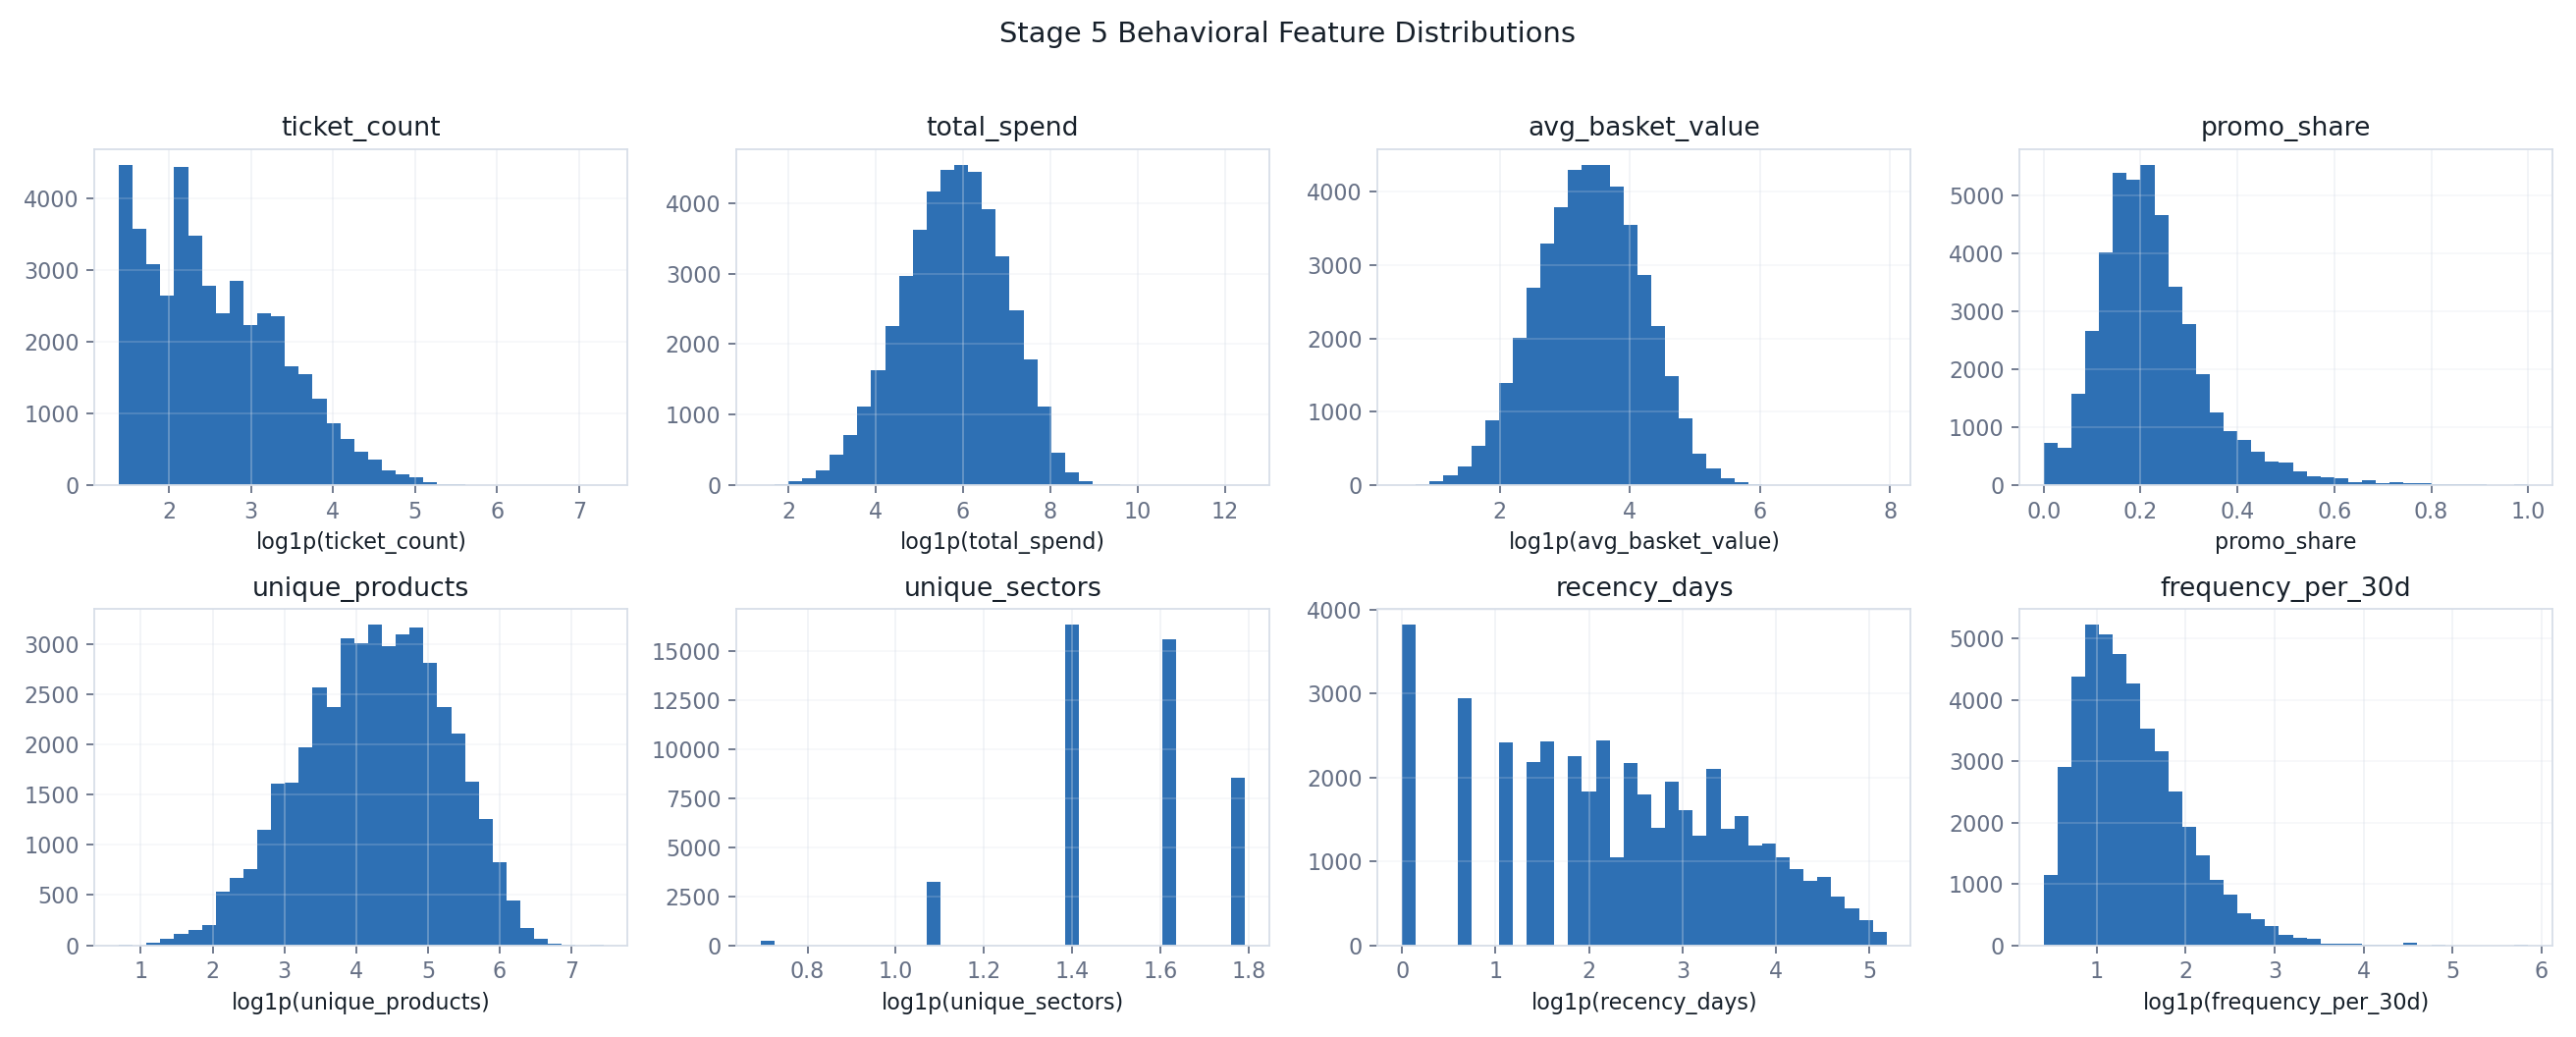

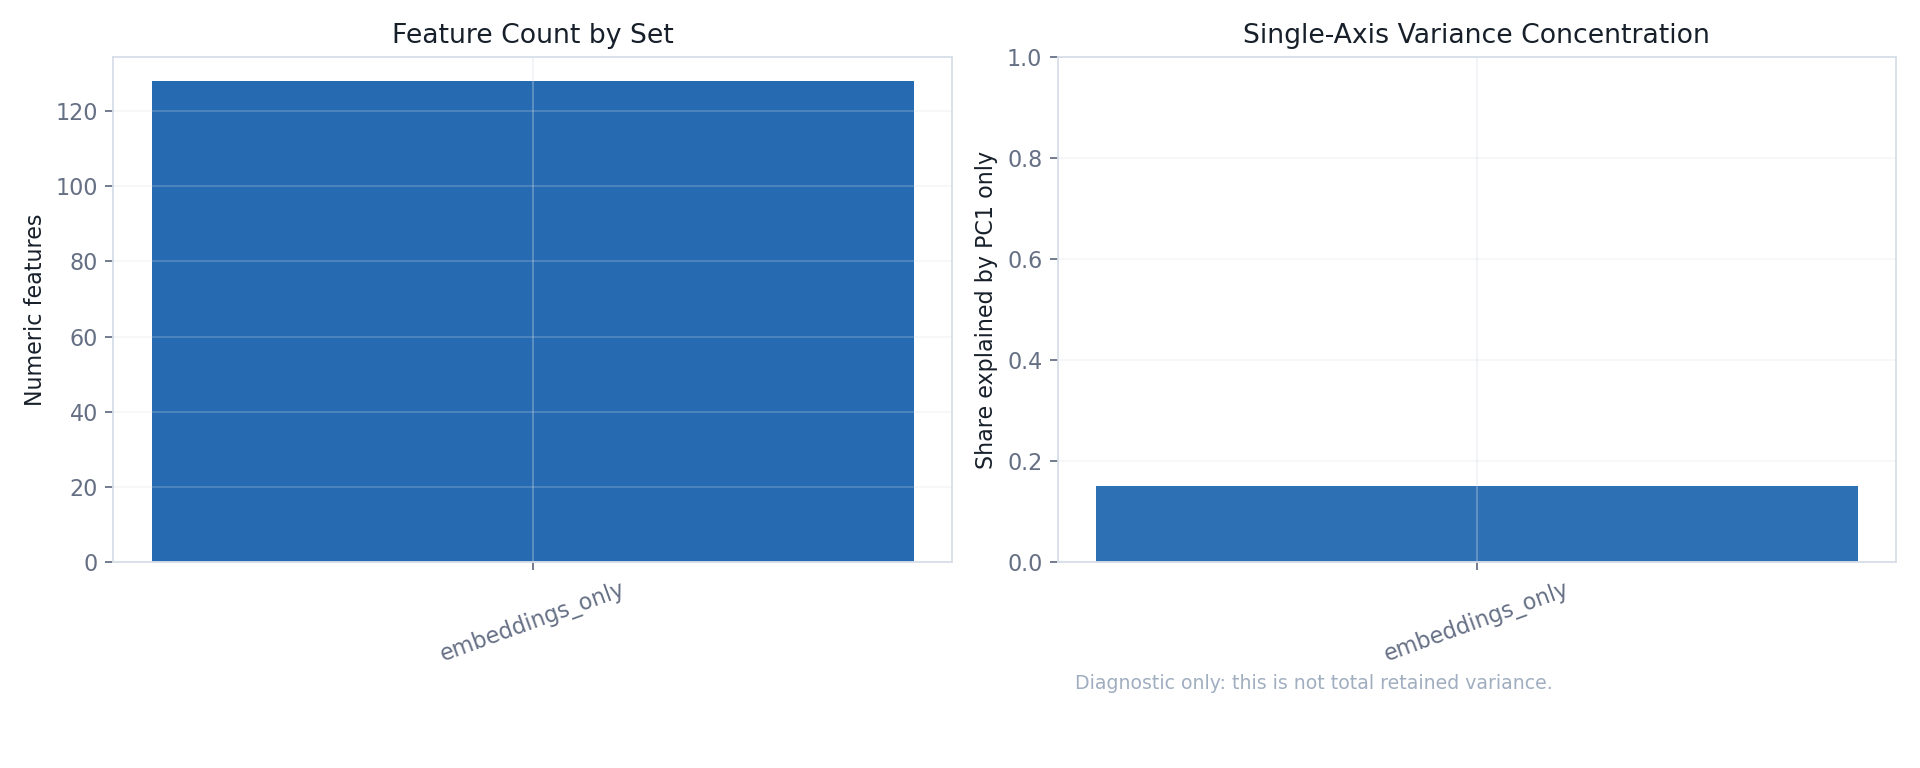

feature_set_name,is_selection_feature_set,rows,feature_count,finite_pct,null_pct,zero_variance_feature_count,customer_alignment_status,missing_vs_baseline_customers,extra_vs_baseline_customers,neighbor_overlap_vs_baseline_pct,selection_warning
str,bool,i64,i64,f64,f64,i64,str,i64,i64,f64,str
"""embeddings_only""",true,43963,128,100.0,0.0,0,"""pass""",0,0,100.0,"""OK: official selection uses pr…"


In [ ]:
from IPython.display import Image
import polars as pl

from src.feature_engineering import build_behavioral_features, build_feature_set, build_feature_set_diagnostics, build_product_exposure_features
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_behavioral_feature_summary, plot_feature_set_summary

behavior_path = build_behavioral_features(transactions=transactions, cfg=CONFIG)
selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
build_product_exposure_challenger = bool(CONFIG.get("product_exposure_features.enabled", False)) or selection_feature_set == "embeddings_product_exposure"
product_exposure_path = None
embeddings_only_feature_set = build_feature_set(customer_embeddings_path, variant="embeddings_only", cfg=CONFIG)
feature_sets = {"embeddings_only": embeddings_only_feature_set}
if build_product_exposure_challenger:
    product_exposure_path = build_product_exposure_features(transactions=transactions, cfg=CONFIG)
    feature_sets["embeddings_product_exposure"] = build_feature_set(
        customer_embeddings_path,
        product_exposure_path=product_exposure_path,
        variant="embeddings_product_exposure",
        cfg=CONFIG,
    )
stage5_behavior_figure = plot_behavioral_feature_summary(behavior_path, cfg=CONFIG)
stage5_feature_set_figure = plot_feature_set_summary(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics_path = build_feature_set_diagnostics(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics = pl.read_csv(stage5_feature_diagnostics_path)
stage5_diagnostic_display_cols = [
    "feature_set_name",
    "is_selection_feature_set",
    "rows",
    "feature_count",
    "finite_pct",
    "null_pct",
    "zero_variance_feature_count",
    "customer_alignment_status",
    "missing_vs_baseline_customers",
    "extra_vs_baseline_customers",
    "neighbor_overlap_vs_baseline_pct",
    "selection_warning",
]
stage5_report = write_stage_report(
    "05",
    "Official Product/Quantity Feature Set",
    summary=[
        "Official tribe selection uses embeddings_only to keep clustering product-first.",
        "Behavioral features are prepared separately for post-clustering interpretation.",
        "Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.",
    ],
    metrics={
        "feature_sets_built": len(feature_sets),
        "selection_feature_set": CONFIG.get("modeling.feature_set_for_selection", "embeddings_only"),
        "feature_diagnostics_rows": stage5_feature_diagnostics.height,
        "product_exposure_challenger_enabled": build_product_exposure_challenger,
    },
    figures={
        "Behavioral feature summary": stage5_behavior_figure,
        "Feature set summary": stage5_feature_set_figure,
    },
    artifacts={
        **{"Behavioral features": behavior_path, "Feature diagnostics": stage5_feature_diagnostics_path},
        **({"Product exposure features": product_exposure_path} if product_exposure_path is not None else {}),
        **feature_sets,
    },
    cfg=CONFIG,
)
display_stage_report(stage5_report)
display(Image(filename=str(stage5_behavior_figure)))
display(Image(filename=str(stage5_feature_set_figure)))
display(stage5_feature_diagnostics.select([c for c in stage5_diagnostic_display_cols if c in stage5_feature_diagnostics.columns]))


<a id="stage-6"></a>

## Stage 6: Hard Two-Stage UMAP-HDBSCAN Core Tribe Discovery

This is the official organic-tribe discovery step. It uses the selected product/quantity customer feature set, builds a UMAP representation for clustering, then runs hard HDBSCAN in two visible passes. Customers labeled `-1` are not forced into a tribe; they are the honest non-core population for this recipe.

- Stage 6.1 builds the UMAP customer manifold from `embeddings_only`.
- Stage 6.2 runs the first hard HDBSCAN pass on the full UMAP representation.
- Stage 6.3 runs a stricter second hard HDBSCAN pass only on first-pass noise.
- Stage 6.4 merges first-pass cores and second-pass noise cores, then keeps only clusters with strong product-lift evidence.
- Stage 6.5 writes representation and density-quality evidence for the merged official assignment.
- Stage 6.6 checks cluster-level stability, confidence, and profile readiness before Stage 7 interpretation.

UMAP is treated as a clustering representation, not as automatic proof. The final claim is only credible when the two HDBSCAN passes, merged density evidence, Stage 6.6 stability/readiness, and Stage 7 product-lift profiles agree.


In [ ]:
import polars as pl
from IPython.display import Image, Markdown, display

from src.model_selection import (
    build_candidate_model_diagnostics,
    build_official_umap_core_representation,
    build_stage6_hdbscan_diagnostics,
    build_stage6_representation_cluster_diagnostics,
    build_stage6_umap_diagnostics,
    merge_official_two_stage_hdbscan_lift_core,
    model_suite_from_single_candidate,
    run_official_two_stage_hdbscan_first_pass,
    run_official_two_stage_hdbscan_second_pass,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_stage6_hdbscan_assignment_map,
    plot_stage6_quality_evidence,
    plot_stage6_umap_representation,
)

selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
if "feature_sets" not in globals():
    feature_set_outputs = CONFIG.get("feature_sets.outputs", {})
    selection_feature_filename = feature_set_outputs.get(selection_feature_set, f"feature_set_{selection_feature_set}.parquet")
    feature_sets = {
        selection_feature_set: CONFIG.outputs / "features" / selection_feature_filename,
    }
    missing_feature_sets = [path for path in feature_sets.values() if not path.exists()]
    if missing_feature_sets:
        raise FileNotFoundError(
            "Stage 6 needs the Stage 5 feature-set parquet files. "
            f"Missing: {missing_feature_sets}. Run Stage 5 first."
        )

allowed_product_feature_sets = {"embeddings_only", "embeddings_product_exposure"}
if selection_feature_set not in allowed_product_feature_sets:
    raise ValueError(
        "Official Stage 6 core tribe discovery only allows product-derived feature sets: "
        f"{sorted(allowed_product_feature_sets)}. Do not use behavior, spend, or demographic feature sets here."
    )
stage6_feature_path = feature_sets[selection_feature_set]
stage6_feature_path


WindowsPath('C:/Users/rothl/Desktop/IE Capstone/carrefour_capstone/outputs/dev/features/feature_set_embeddings_only.parquet')

### Stage 6.1: UMAP Representation Check

Build the official PCA-to-UMAP customer manifold from the product/quantity feature set. The PCA overview records why the pre-reduction exists, how many dimensions it keeps before UMAP, and how much standardized variance is retained; the UMAP checks then stop the run if row alignment, dimensionality, nulls, or finite-value checks fail.

[13:15:44] Stage 6.1 UMAP: building product-only customer manifold | trial=u20_n75_eom_mcs550_ms2_core, pca_components=64, components=20, n_neighbors=75
[13:16:03] Stage 6 UMAP: building clustering representation | components=20, n_neighbors=75, metric=cosine, source_rows=43963, fit_sample_size=43963
[13:18:42] Stage 6 UMAP: wrote artifact | rows=43963, fit_sample_rows=43963, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\feature_set_umap_pca64_u20_n75.parquet
[13:18:42] Stage 6 UMAP: finished | elapsed_s=158.8000
[13:18:43] Stage 6.1 checks: wrote UMAP representation diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_1_umap_checks.csv
[13:18:43] Stage 6.1 figures: wrote UMAP representation preview | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_1_umap_representation.png


purpose,dimension_reduction,requested_component_count,retained_component_count,retained_variance_pct,pc1_variance_pct,pc5_cumulative_variance_pct,pc10_cumulative_variance_pct
str,str,i64,i64,f64,f64,f64,f64
"""Pre-reduce standardized custom…","""128 -> 64""",64,64,86.36,12.75,38.89,51.91


stage,check_status,check_issues,feature_path,umap_path,source_rows,umap_rows,missing_feature_customers,extra_umap_customers,duplicate_umap_customers,source_feature_count,umap_component_count,requested_umap_components,umap_n_neighbors,umap_metric,umap_min_dist,finite_pct,null_pct,zero_variance_component_count,pca_pre_reduction_summary_status,pca_summary_path,pca_purpose,pca_dimension_reduction,pca_input_dimension_count,pca_requested_component_count,pca_retained_component_count,pca_retained_variance_pct,pca_pc1_variance_pct,pca_pc5_cumulative_variance_pct,pca_pc10_cumulative_variance_pct
str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,i64,str,str,str,str,i64,i64,i64,f64,f64,f64,f64
"""6.1_umap_representation""","""pass""","""pass""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",43963,43963,0,0,0,128,20,20,75,"""cosine""",0.0,100.0,0.0,0,"""present""","""C:\Users\rothl\Desktop\IE Caps…","""Pre-reduce standardized custom…","""128 -> 64""",128,64,64,86.363658,12.745196,38.8899,51.909597


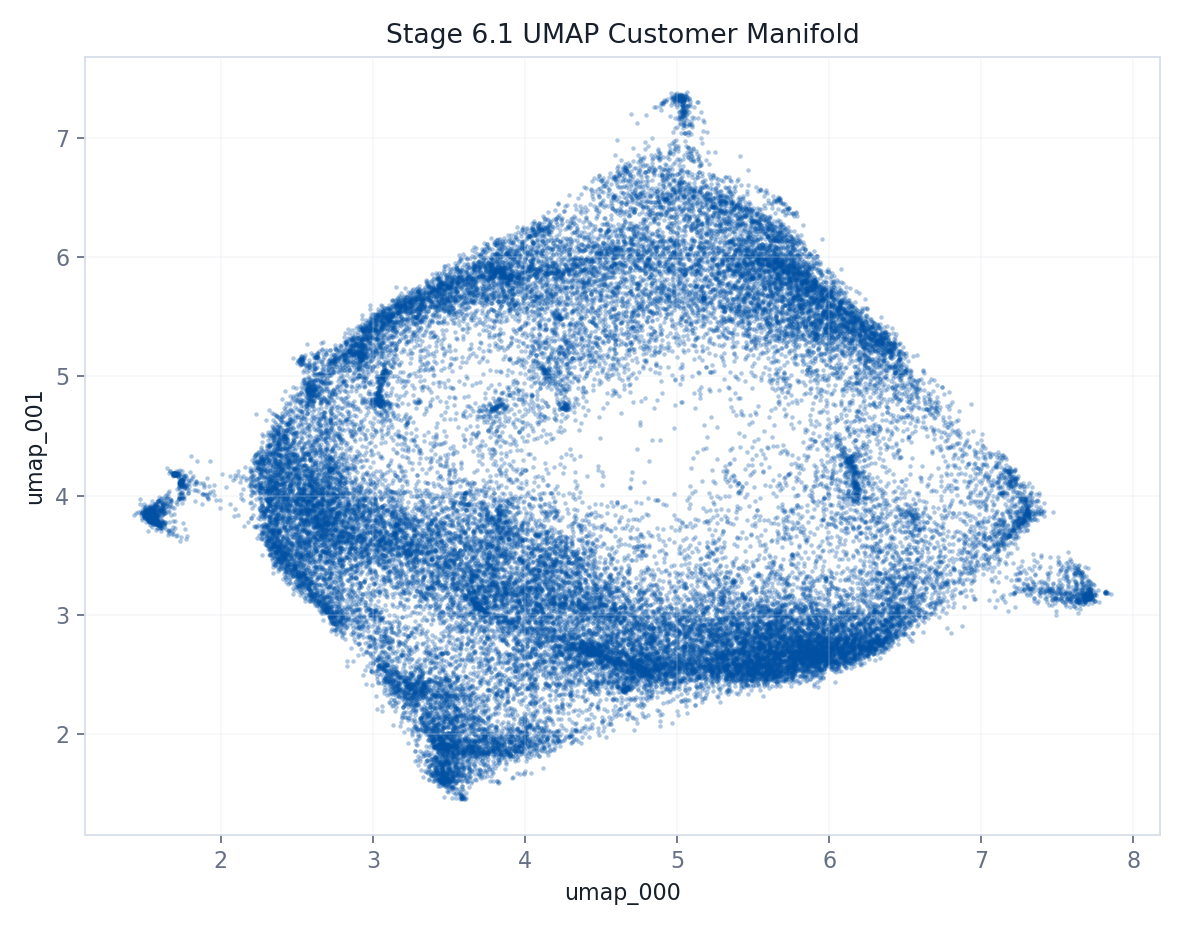

In [ ]:
stage6_umap_path = build_official_umap_core_representation(stage6_feature_path, cfg=CONFIG)
stage6_umap_checks_path = build_stage6_umap_diagnostics(stage6_feature_path, stage6_umap_path, cfg=CONFIG)
stage6_umap_checks = pl.read_csv(stage6_umap_checks_path)
stage6_pca_summary_path = CONFIG.artifacts / "stage6" / "stage6_1_pca_for_umap_summary.csv"
stage6_pca_summary = pl.read_csv(stage6_pca_summary_path)
stage6_pca_overview = stage6_pca_summary.select(
    [
        "purpose",
        "dimension_reduction",
        "requested_component_count",
        "retained_component_count",
        pl.col("retained_variance_pct").round(2),
        pl.col("pc1_variance_pct").round(2),
        pl.col("pc5_cumulative_variance_pct").round(2),
        pl.col("pc10_cumulative_variance_pct").round(2),
    ]
)
stage6_umap_figure = plot_stage6_umap_representation(stage6_umap_path, cfg=CONFIG)

display(stage6_pca_overview)
display(stage6_umap_checks)
display(Image(filename=str(stage6_umap_figure)))
if stage6_umap_checks[0, "check_status"] != "pass":
    raise ValueError(f"Stage 6.1 UMAP checks failed: {stage6_umap_checks[0, 'check_issues']}")


### Stage 6.2: First Hard HDBSCAN Pass

Run hard HDBSCAN on the full UMAP representation. This produces the first set of core tribes plus the first-pass noise population that Stage 6.3 will inspect separately.


[13:18:43] Stage 6 HDBSCAN: fitting density model | model=model_d_two_stage_hdbscan_lift_core_stage1, feature_space=umap_customer_embeddings_pca64_u20_n75, min_cluster_size=200, min_samples=8


c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[13:18:50] Stage 6 HDBSCAN: finished | elapsed_s=7.4000
[13:18:54] Stage 6 HDBSCAN: model evaluated | clusters=28, noise_pct=69.6836, passes_gate=False, source=hdbscan_fit, soft_assigned=0
[13:18:54] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_2_first_hdbscan_checks.csv
[13:18:55] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_2_first_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.2_first_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",43963,43963,0,0,0,28,13328,30635,69.6836,30.3164,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",30635
"""hdbscan_fit""",13328


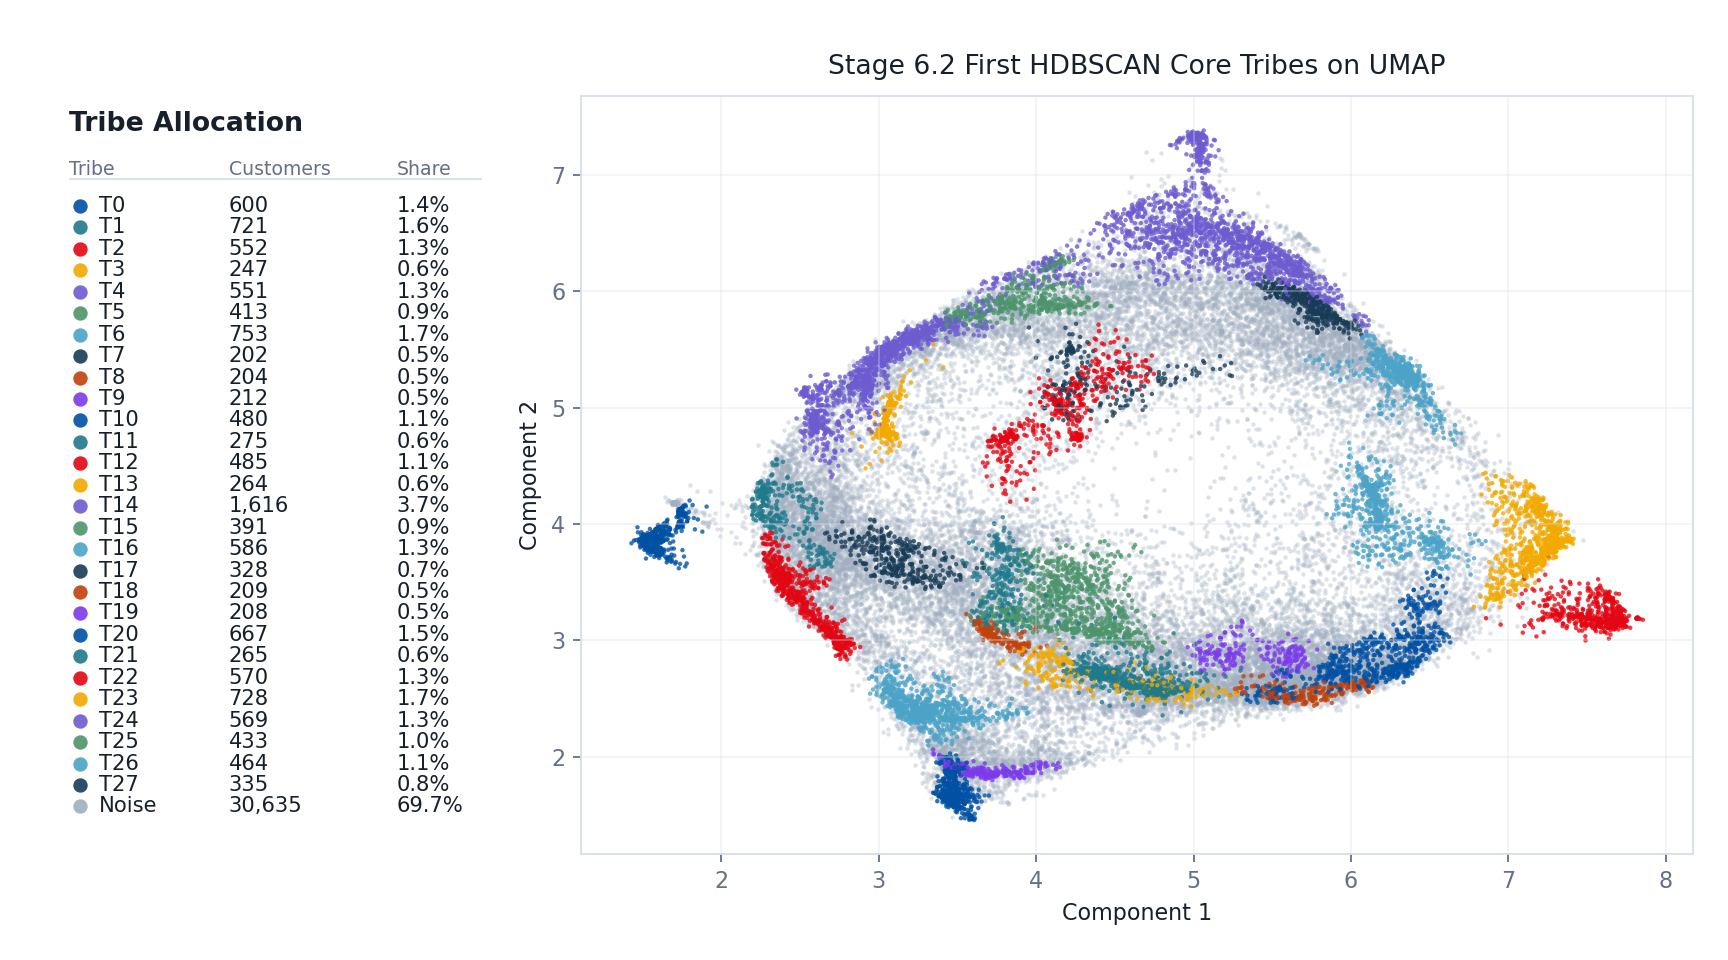

In [ ]:
stage6_stage1_assignment_path, stage6_stage1_result_path, stage6_stage1_candidate = run_official_two_stage_hdbscan_first_pass(
    stage6_umap_path,
    cfg=CONFIG,
)
stage6_stage1_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    stage6_stage1_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_2_first_hdbscan_checks.csv",
    stage_name="6.2_first_hdbscan",
    cfg=CONFIG,
)
stage6_stage1_checks = pl.read_csv(stage6_stage1_checks_path)
stage6_stage1_assignment_source_table = (
    pl.read_parquet(stage6_stage1_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_stage1_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    output_path=CONFIG.figures / "stage6_2_first_hdbscan_assignment_map.png",
    title="Stage 6.2 First HDBSCAN Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_stage1_checks)
display(stage6_stage1_assignment_source_table)
display(Image(filename=str(stage6_stage1_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage1_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage1_checks.columns else "check_issues"
if stage6_stage1_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.2 first HDBSCAN structural checks failed: {stage6_stage1_checks[0, blocking_issues_col]}")


### Stage 6.3: Stricter HDBSCAN Pass Over First-Pass Noise

Run a stricter second HDBSCAN only on customers that were noise in Stage 6.2. This pass is allowed to recover dense pockets from noise, but it uses the less-eager second-pass config and still keeps remaining noise unassigned.


[13:18:55] Stage 6 HDBSCAN: fitting density model | model=model_d_two_stage_hdbscan_lift_core_stage2, feature_space=umap_customer_embeddings_pca64_u20_n75_stage1_noise, min_cluster_size=150, min_samples=5


c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\rothl\miniconda3\envs\carrefour\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[13:19:01] Stage 6 HDBSCAN: finished | elapsed_s=5.7000
[13:19:02] Stage 6 HDBSCAN: model evaluated | clusters=14, noise_pct=83.1141, passes_gate=False, source=hdbscan_fit, soft_assigned=0
[13:19:02] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_3_second_noise_hdbscan_checks.csv
[13:19:02] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_3_second_noise_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.3_second_noise_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",30635,30635,0,0,0,14,5173,25462,83.1141,16.8859,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",25462
"""hdbscan_fit""",5173


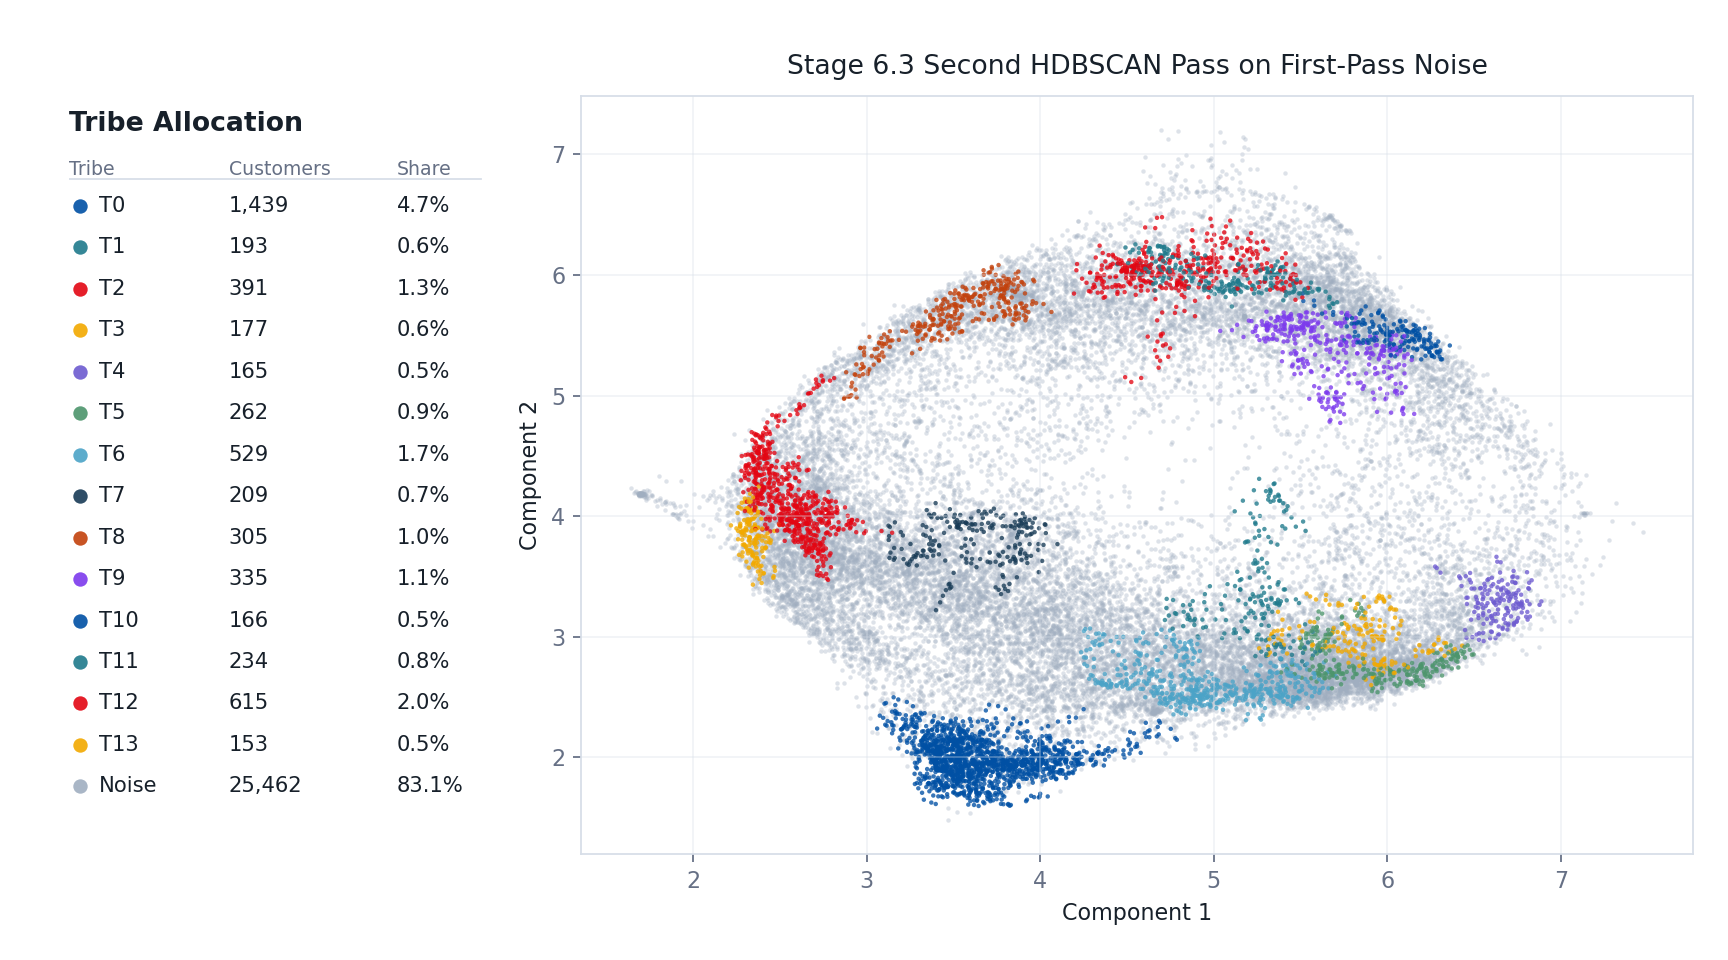

In [ ]:
(
    stage6_stage2_noise_feature_path,
    stage6_stage2_noise_customers,
    stage6_stage2_assignment_path,
    stage6_stage2_result_path,
    stage6_stage2_candidate,
) = run_official_two_stage_hdbscan_second_pass(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    cfg=CONFIG,
)

if stage6_stage2_assignment_path is not None and stage6_stage2_result_path is not None:
    stage6_stage2_checks_path = build_stage6_hdbscan_diagnostics(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        stage6_stage2_result_path,
        output_path=CONFIG.artifacts / "stage6" / "stage6_3_second_noise_hdbscan_checks.csv",
        stage_name="6.3_second_noise_hdbscan",
        cfg=CONFIG,
    )
    stage6_stage2_checks = pl.read_csv(stage6_stage2_checks_path)
    stage6_stage2_assignment_source_table = (
        pl.read_parquet(stage6_stage2_assignment_path)
        .group_by("assignment_source")
        .agg(pl.len().alias("customers"))
        .sort("customers", descending=True)
    )
    stage6_stage2_figure = plot_stage6_hdbscan_assignment_map(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        output_path=CONFIG.figures / "stage6_3_second_noise_hdbscan_assignment_map.png",
        title="Stage 6.3 Second HDBSCAN Pass on First-Pass Noise",
        cfg=CONFIG,
    )
    display(stage6_stage2_checks)
    display(stage6_stage2_assignment_source_table)
    display(Image(filename=str(stage6_stage2_figure)))
    blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage2_checks.columns else "check_status"
    blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage2_checks.columns else "check_issues"
    if stage6_stage2_checks[0, blocking_status_col] != "pass":
        raise ValueError(f"Stage 6.3 second HDBSCAN structural checks failed: {stage6_stage2_checks[0, blocking_issues_col]}")
else:
    stage6_stage2_checks_path = None
    stage6_stage2_figure = None
    stage6_stage2_assignment_source_table = pl.DataFrame()
    stage6_stage2_checks = pl.DataFrame([
        {
            "stage": "6.3_second_noise_hdbscan",
            "check_status": "skipped",
            "check_issues": "first-pass noise below second-pass min_cluster_size",
            "noise_customers": stage6_stage2_noise_customers,
        }
    ])
    display(Markdown(
        f"Stage 6.3 skipped: first-pass noise customers ({stage6_stage2_noise_customers:,}) "
        "are below the configured second-pass min_cluster_size."
    ))
    display(stage6_stage2_checks)


### Stage 6.4: Merge Passes and Apply Product-Lift Filter

Merge Stage 6.2 first-pass cores with Stage 6.3 second-pass noise cores, then keep only clusters with enough strong significant product-lift evidence. This merged file is the official assignment used downstream.


In [ ]:
stage6_assignment_path, stage6_result_path, stage6_core_candidate = merge_official_two_stage_hdbscan_lift_core(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    stage1_results_path=stage6_stage1_result_path,
    stage2_assignment_path=stage6_stage2_assignment_path,
    stage2_results_path=stage6_stage2_result_path,
    stage2_noise_feature_path=stage6_stage2_noise_feature_path,
    stage2_noise_customers=stage6_stage2_noise_customers,
    cfg=CONFIG,
)
stage6_hdbscan_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_4_merged_hdbscan_checks.csv",
    stage_name="6.4_merged_two_stage_lift_core",
    cfg=CONFIG,
)
stage6_hdbscan_checks = pl.read_csv(stage6_hdbscan_checks_path)
stage6_assignment_source_table = (
    pl.read_parquet(stage6_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_lift_evidence_path = stage6_core_candidate.get("lift_filter_evidence_csv_path")
stage6_lift_evidence = pl.read_csv(stage6_lift_evidence_path) if stage6_lift_evidence_path else pl.DataFrame()
stage6_assignment_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_assignment_path,
    output_path=CONFIG.figures / "stage6_4_merged_hdbscan_assignment_map.png",
    title="Stage 6.4 Merged Two-Stage HDBSCAN Lift-Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_hdbscan_checks)
display(stage6_assignment_source_table)
if not stage6_lift_evidence.is_empty():
    display(stage6_lift_evidence)
display(Image(filename=str(stage6_assignment_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_hdbscan_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_hdbscan_checks.columns else "check_issues"
if stage6_hdbscan_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.4 merged HDBSCAN structural checks failed: {stage6_hdbscan_checks[0, blocking_issues_col]}")


[13:19:02] Stage 7 profiling: building tribe profile | assignments=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_d_two_stage_hdbscan_lift_core_unfiltered.parquet
[13:19:03] Stage 7 profiling: assignment population | clusters=42, customers=43963, noise_customers=25462, model=model_d_two_stage_hdbscan_lift_core, variant=two_stage_u20_n75_eom_mcs550_ms2_stage1_mcs200_ms8_leaf_stage2_mcs150_ms5_leaf_lift
[13:19:03] Stage 7 profiling: aggregating population product counts | min_product_customers=10
[13:19:03] Stage 7 profiling: aggregating product metadata
[13:19:04] Stage 7 profiling: population product counts ready | products=77992
[13:19:04] Stage 7 profiling: aggregating tribe product lifts
[13:19:05] Stage 7 profiling: tribe product lifts ready | rows=36099
[13:19:05] Stage 7 profiling: building product theme map


### Stage 6.5: Representation and Merged Core-Cluster Quality Evidence

Write the official Stage 6 evidence after 6.1-6.4 have produced the merged, lift-filtered hard assignment. Because UMAP has no PCA-style variance retention, this cell checks neighborhood retention; for HDBSCAN it reports density validity, noise, balance, and core-only separation evidence.


[13:09:34] Experiment summary: wrote human-readable summaries | rows=1, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\model_selection\stage6_candidate_model_summary.csv
[13:09:34] Stage 6 diagnostics: wrote candidate diagnostics | candidates=1, parquet=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\model_selection\stage6_candidate_model_diagnostics.parquet, summary_csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\model_selection\stage6_candidate_model_summary.csv
[13:09:52] Stage 6.5 diagnostics: wrote representation and cluster quality evidence | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_5_representation_cluster_quality.csv
[13:09:53] Stage 6.5 diagnostics: wrote quality evidence scorecard | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_5_quality_evidence.png


# Stage 06: Hard Two-Stage UMAP-HDBSCAN Core Tribe Discovery

- Mode: `dev`

## Status
- Selection feature set: embeddings_only (official signal is product identity, quantity, and optional product-derived exp...
- Stage 6.1 PCA pre-reduces 128 -> 64 dimensions and retains 86.4% standardized variance before UMAP.
- Stage 6.1 builds the UMAP customer manifold; Stage 6.2 runs first-pass hard HDBSCAN; Stage 6.3 reruns stricter HDBSCAN ...
- Stage 6.4 merges both passes and keeps only clusters with strong significant product-lift evidence.
- Stage 6.5 reports UMAP neighborhood retention and density-aware HDBSCAN validity evidence for the merged official assig...
- Official core model: model_d_two_stage_hdbscan_lift_core / two_stage_u20_n75_eom_mcs550_ms2_stage1_mcs550_ms2_eom_stage...

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| pca_dimension_reduction | 128 -> 64 | pre-UMAP PCA reduction |
| pca_retained_variance_pct | 86.364 | standardized variance retained before UMAP |
| first_pass_cluster_count | 2 | diagnostic first pass |
| first_pass_noise_pct | 0 | noise inspected in Stage 6.3 |
| second_pass_cluster_count | 0 | recovered from first-pass noise |
| second_pass_noise_customers | 0 | remaining candidates for second pass |
| unfiltered_cluster_count | 2 | before product-lift filtering |
| lift_supported_cluster_count | 1 | official retained clusters |
| lift_rejected_cluster_count | 1 | clusters rejected for weak product evidence |
| cluster_count | 1 | 10-15 client hypothesis; not a hard constraint |
| noise_pct | 98.665 | <= 60% quality gate; <= 40% strong |
| core_coverage_pct | 1.335 | >= 40% useful; >= 60% strong |
| quality_gate_status | fail | pass |
| quality_gate_issues | cluster_count<2; silhouette<0.0; noise_pct>60.0 | pass / None |
| umap_trustworthiness | 0.9009 | >= 0.95 strong; >= 0.90 usable |
| umap_mean_knn_overlap_pct | 17.035 | >= 25% useful; >= 15% review |
| umap_distance_spearman | 0.4231 | >= 0.70 strong; >= 0.60 usable |
| hdbscan_dbcv_score | None | >= 0.25 strong; >= 0.10 usable; near 0 weak |
| hdbscan_dbcv_status | not_run | computed / unavailable / failed |
| silhouette_core_only | None | >= 0.40 strong; >= 0.25 usable |
| coverage_adjusted_silhouette | None | >= 0.25 strong; >= 0.15 usable |
| davies_bouldin_core_only | None | lower is better; < 1.0 usually usable |
| avg_assignment_confidence | 0.9887 | >= 0.40 stronger; >= 0.30 review |
| assignment_policy | hard_two_stage_hdbscan_lift_core_noise_retained | hard_two_stage_hdbscan_lift_core_noise_retained |
| soft_assigned_pct | 0 | 0% for official hard-core recipe |

## Visual Evidence
- Stage 6.1 UMAP representation: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_1_umap_representation.png`
- Stage 6.2 first HDBSCAN assignment map: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_2_first_hdbscan_assignment_map.png`
- Stage 6.4 merged lift-core assignment map: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_4_merged_hdbscan_assignment_map.png`
- Stage 6.5 representation and density evidence: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_5_quality_evidence.png`

## Artifacts
- Stage 6.1 PCA summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_1_pca_for_umap_summary.csv`
- UMAP representation: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\feature_set_umap_pca40_u20_n75.parquet`
- Stage 6.1 UMAP checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_1_umap_checks.csv`
- Stage 6.2 first-pass assignments: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_d_two_stage_hdbscan_lift_core_stage1.parquet`
- Stage 6.2 first-pass checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_2_first_hdbscan_checks.csv`
- Stage 6.3 noise feature subset: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\model_selection\model_d_two_stage_hdbscan_lift_core_stage2_noise_features.parquet`
- Stage 6.4 merged lift-core assignments: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_d_two_stage_hdbscan_lift_core.parquet`
- Stage 6.4 merged checks: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_4_merged_hdbscan_checks.csv`
- Stage 6.4 lift filter evidence: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\model_d_two_stage_hdbscan_lift_core_...`
- Stage 6.5 representation and cluster quality CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_5_representation_cluster_quality.csv`
- Diagnostics parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\model_selection\stage6_candidate_model_diagnostics.parquet`
- Diagnostics summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\model_selection\stage6_candidate_model_summary.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

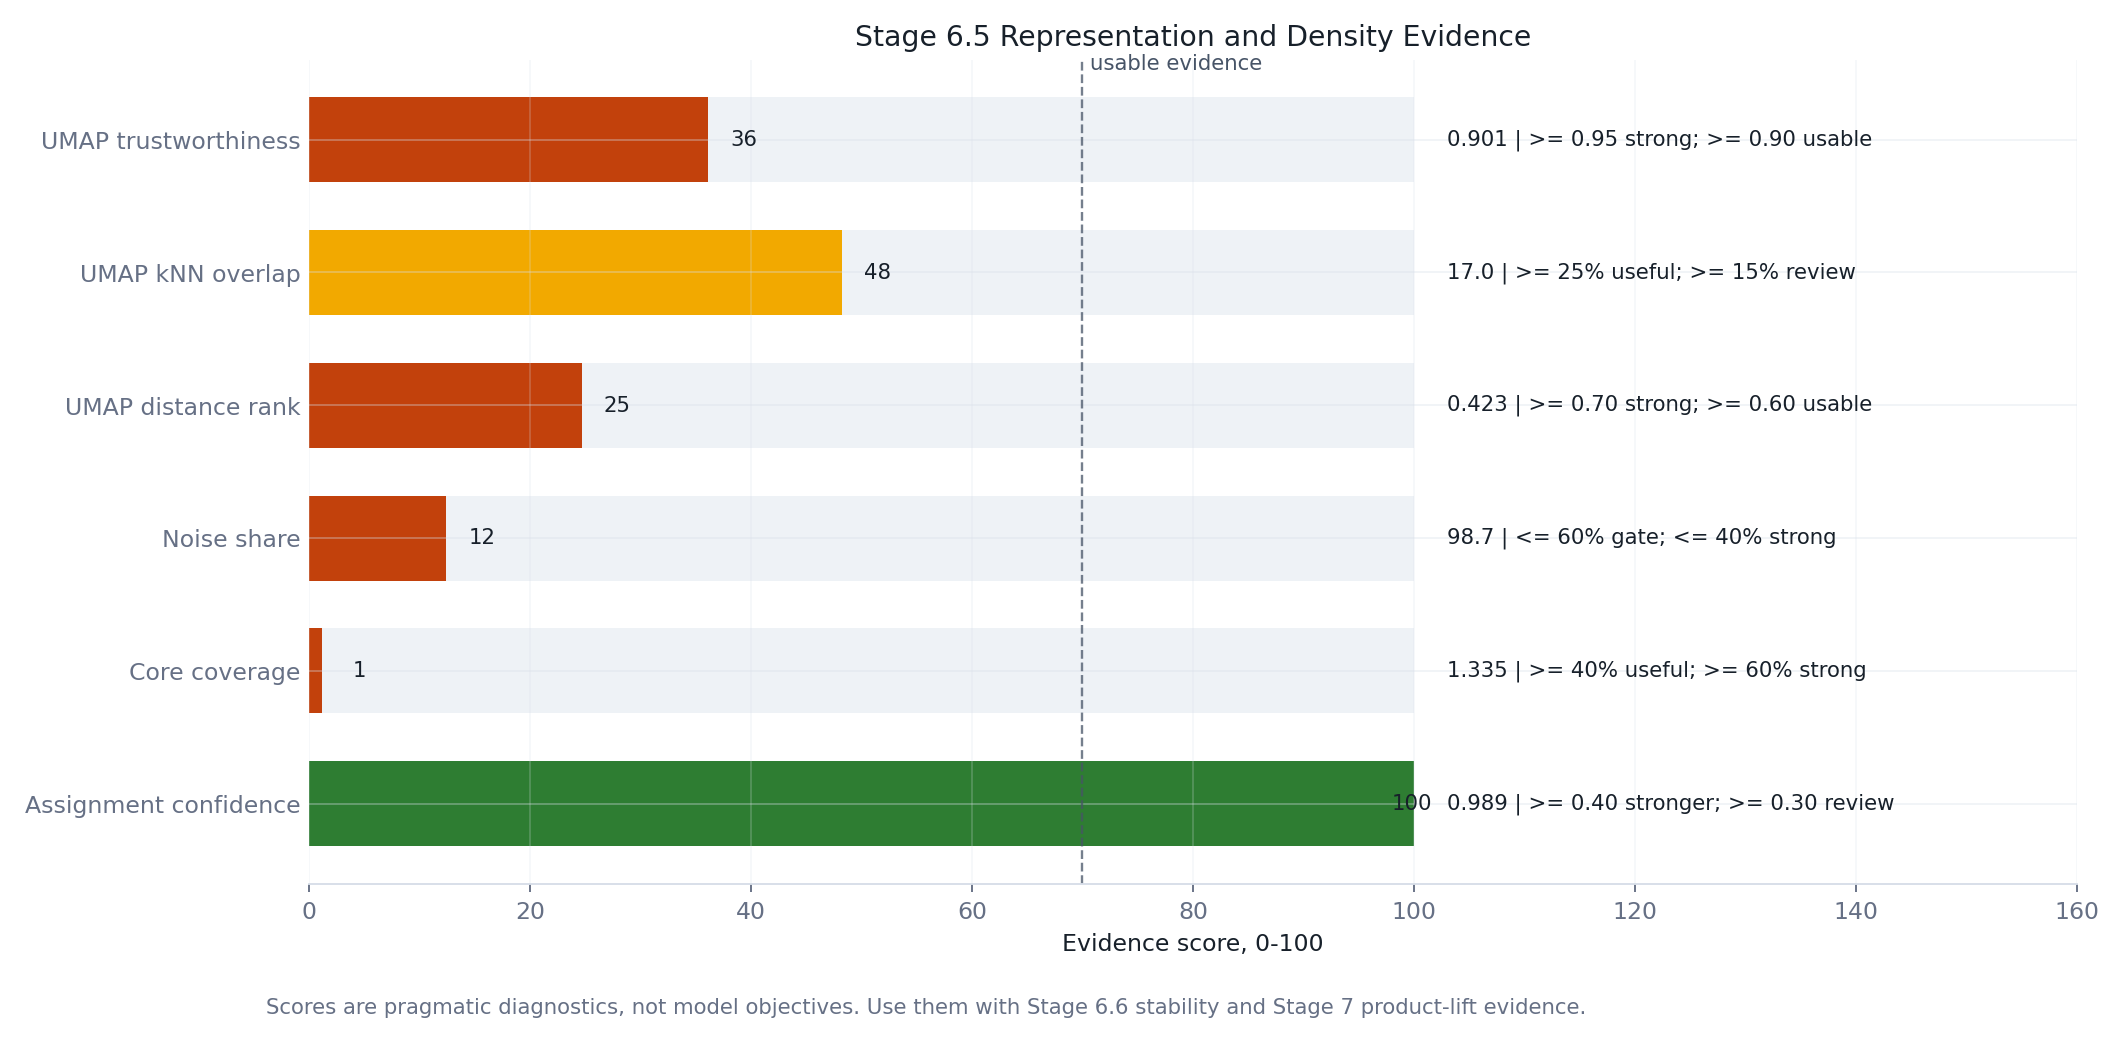

aligned_rows,source_feature_count,umap_component_count,umap_quality_sample_size,umap_neighbor_k,umap_trustworthiness,umap_mean_knn_overlap_pct,umap_distance_spearman,cluster_count,noise_pct,core_coverage_pct,hdbscan_dbcv_score,hdbscan_dbcv_status,silhouette_core_only,coverage_adjusted_silhouette,davies_bouldin_core_only,avg_assignment_confidence,hdbscan_cluster_persistence_mean
i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str,str,str,str,str,f64,str
43963,128,20,5000,15,0.900888,17.034668,0.423128,1,98.6648,1.3352,null,"""not_run""",null,null,null,0.988683,null


stage6_rank,candidate_id,model_name,algorithm_name,assignment_policy,model_variant,cluster_count,coverage_adjusted_silhouette,silhouette,davies_bouldin,noise_pct,core_coverage_pct,soft_assigned_pct,lift_supported_cluster_count,lift_rejected_cluster_count,passes_quality_gate
i64,str,str,str,str,str,i64,null,null,null,f64,f64,f64,i64,i64,bool
1,"""model_d_two_stage_hdbscan_lift…","""model_d_two_stage_hdbscan_lift…","""UMAP_HDBSCAN_TwoStageLiftCore""","""hard_two_stage_hdbscan_lift_co…","""two_stage_u20_n75_eom_mcs550_m…",1,null,null,null,98.6648,1.3352,0.0,1,1,false


assignment_source,customers
str,u32
"""two_stage_hdbscan_lift_rejecte…",43376
"""two_stage_hdbscan_stage1_core""",587


In [ ]:
model_suite = model_suite_from_single_candidate(
    stage6_assignment_path,
    stage6_result_path,
    stage6_core_candidate,
    umap_path=stage6_umap_path,
)
stage6_diagnostics = build_candidate_model_diagnostics(model_suite, cfg=CONFIG)
stage6_quality_path = build_stage6_representation_cluster_diagnostics(
    stage6_feature_path,
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_5_representation_cluster_quality.csv",
    cfg=CONFIG,
)
stage6_quality = pl.read_csv(stage6_quality_path)
stage6_figure = plot_stage6_quality_evidence(
    stage6_quality_path,
    output_path=CONFIG.figures / "stage6_5_quality_evidence.png",
    title="Stage 6.5 Representation and Density Evidence",
    cfg=CONFIG,
)
stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_quality_display_cols = [
    "aligned_rows",
    "source_feature_count",
    "umap_component_count",
    "umap_quality_sample_size",
    "umap_neighbor_k",
    "umap_trustworthiness",
    "umap_mean_knn_overlap_pct",
    "umap_distance_spearman",
    "cluster_count",
    "noise_pct",
    "core_coverage_pct",
    "hdbscan_dbcv_score",
    "hdbscan_dbcv_status",
    "silhouette_core_only",
    "coverage_adjusted_silhouette",
    "davies_bouldin_core_only",
    "avg_assignment_confidence",
    "hdbscan_cluster_persistence_mean",
]
stage6_quality_table = stage6_quality.select([c for c in stage6_quality_display_cols if c in stage6_quality.columns])
stage6_display_cols = [
    "stage6_rank",
    "candidate_id",
    "model_name",
    "algorithm_name",
    "assignment_policy",
    "model_variant",
    "cluster_count",
    "coverage_adjusted_silhouette",
    "silhouette",
    "davies_bouldin",
    "noise_pct",
    "core_coverage_pct",
    "soft_assigned_pct",
    "lift_supported_cluster_count",
    "lift_rejected_cluster_count",
    "passes_quality_gate",
]
stage6_table = stage6_ranked.select([c for c in stage6_display_cols if c in stage6_ranked.columns])
stage6_best = stage6_ranked.row(0, named=True)
stage6_quality_best = stage6_quality.row(0, named=True)
stage6_report_metrics = [
    ("pca_dimension_reduction", stage6_pca_summary[0, "dimension_reduction"], "pre-UMAP PCA reduction"),
    ("pca_retained_variance_pct", stage6_pca_summary[0, "retained_variance_pct"], "standardized variance retained before UMAP"),
    ("first_pass_cluster_count", stage6_stage1_candidate.get("cluster_count"), "diagnostic first pass"),
    ("first_pass_noise_pct", stage6_stage1_candidate.get("noise_pct"), "noise inspected in Stage 6.3"),
    ("second_pass_cluster_count", stage6_stage2_candidate.get("cluster_count"), "recovered from first-pass noise"),
    ("second_pass_noise_customers", stage6_stage2_noise_customers, "remaining candidates for second pass"),
    ("unfiltered_cluster_count", stage6_best.get("unfiltered_cluster_count"), "before product-lift filtering"),
    ("lift_supported_cluster_count", stage6_best.get("lift_supported_cluster_count"), "official retained clusters"),
    ("lift_rejected_cluster_count", stage6_best.get("lift_rejected_cluster_count"), "clusters rejected for weak product evidence"),
    ("cluster_count", stage6_quality_best.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_quality_best.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("core_coverage_pct", stage6_quality_best.get("core_coverage_pct"), ">= 40% useful; >= 60% strong"),
    ("quality_gate_status", stage6_hdbscan_checks[0, "quality_gate_status"] if "quality_gate_status" in stage6_hdbscan_checks.columns else stage6_best.get("passes_quality_gate"), "pass"),
    ("quality_gate_issues", stage6_hdbscan_checks[0, "quality_gate_issues"] if "quality_gate_issues" in stage6_hdbscan_checks.columns else stage6_best.get("quality_gate_reason"), "pass / None"),
    ("umap_trustworthiness", stage6_quality_best.get("umap_trustworthiness"), ">= 0.95 strong; >= 0.90 usable"),
    ("umap_mean_knn_overlap_pct", stage6_quality_best.get("umap_mean_knn_overlap_pct"), ">= 25% useful; >= 15% review"),
    ("umap_distance_spearman", stage6_quality_best.get("umap_distance_spearman"), ">= 0.70 strong; >= 0.60 usable"),
    ("hdbscan_dbcv_score", stage6_quality_best.get("hdbscan_dbcv_score"), ">= 0.25 strong; >= 0.10 usable; near 0 weak"),
    ("hdbscan_dbcv_status", stage6_quality_best.get("hdbscan_dbcv_status"), "computed / unavailable / failed"),
    ("silhouette_core_only", stage6_quality_best.get("silhouette_core_only"), ">= 0.40 strong; >= 0.25 usable"),
    ("coverage_adjusted_silhouette", stage6_quality_best.get("coverage_adjusted_silhouette"), ">= 0.25 strong; >= 0.15 usable"),
    ("davies_bouldin_core_only", stage6_quality_best.get("davies_bouldin_core_only"), "lower is better; < 1.0 usually usable"),
    ("avg_assignment_confidence", stage6_quality_best.get("avg_assignment_confidence"), ">= 0.40 stronger; >= 0.30 review"),
    ("assignment_policy", stage6_best.get("assignment_policy"), "hard_two_stage_hdbscan_lift_core_noise_retained"),
    ("soft_assigned_pct", stage6_best.get("soft_assigned_pct"), "0% for official hard-core recipe"),
]
stage6_report = write_stage_report(
    "06",
    "Hard Two-Stage UMAP-HDBSCAN Core Tribe Discovery",
    summary=[
        f"Selection feature set: {selection_feature_set} (official signal is product identity, quantity, and optional product-derived exposure; no spend or demographic inputs).",
        f"Stage 6.1 PCA pre-reduces {stage6_pca_summary[0, 'dimension_reduction']} dimensions and retains {stage6_pca_summary[0, 'retained_variance_pct']:.1f}% standardized variance before UMAP.",
        "Stage 6.1 builds the UMAP customer manifold; Stage 6.2 runs first-pass hard HDBSCAN; Stage 6.3 reruns stricter HDBSCAN over first-pass noise.",
        "Stage 6.4 merges both passes and keeps only clusters with strong significant product-lift evidence.",
        "Stage 6.5 reports UMAP neighborhood retention and density-aware HDBSCAN validity evidence for the merged official assignment.",
        f"Official core model: {stage6_best['model_name']} / {stage6_best['model_variant']}",
    ],
    metrics=stage6_report_metrics,
    figures={
        "Stage 6.1 UMAP representation": stage6_umap_figure,
        "Stage 6.2 first HDBSCAN assignment map": stage6_stage1_figure,
        "Stage 6.3 second-pass noise HDBSCAN assignment map": stage6_stage2_figure,
        "Stage 6.4 merged lift-core assignment map": stage6_assignment_figure,
        "Stage 6.5 representation and density evidence": stage6_figure,
    },
    artifacts={
        "Stage 6.1 PCA summary": stage6_pca_summary_path,
        "UMAP representation": model_suite.get("umap_path"),
        "Stage 6.1 UMAP checks": stage6_umap_checks_path,
        "Stage 6.2 first-pass assignments": stage6_stage1_assignment_path,
        "Stage 6.2 first-pass checks": stage6_stage1_checks_path,
        "Stage 6.3 noise feature subset": stage6_stage2_noise_feature_path,
        "Stage 6.3 second-pass assignments": stage6_stage2_assignment_path,
        "Stage 6.3 second-pass checks": stage6_stage2_checks_path,
        "Stage 6.4 merged lift-core assignments": stage6_assignment_path,
        "Stage 6.4 merged checks": stage6_hdbscan_checks_path,
        "Stage 6.4 lift filter evidence": stage6_lift_evidence_path,
        "Stage 6.5 representation and cluster quality CSV": stage6_quality_path,
        "Diagnostics parquet": stage6_diagnostics["parquet"],
        "Diagnostics summary CSV": stage6_diagnostics["summary_csv"],
    },
    cfg=CONFIG,
    max_metric_rows=30,
)
display_stage_report(stage6_report)
display(Image(filename=str(stage6_figure)))
display(stage6_quality_table)
display(stage6_table.head(12))
display(stage6_assignment_source_table)


<a id="stage-6-6"></a>

## Stage 6.6: Cluster Stability and Profile Readiness

Stage 6.6 is the handoff from clustering into profiling. Stage 6.5 already checks representation quality and HDBSCAN density validity; this step asks whether the retained merged clusters themselves are stable enough and confidence-backed enough to interpret.

Use this stage to answer: which clusters are ready for product-lift profiling, and which clusters should be handled cautiously because they are small, low-confidence, or sensitive to perturbation?

The notebook-facing summary is written to `outputs/<mode>/reports/stage_06_6.md`, with cluster readiness, stability diagnostics, and winner projection figures displayed directly below.


[13:09:53] Cluster validity: building validity and stability report | feature_path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet, repeats=5


[13:09:53] Cluster validity: finished | elapsed_s=0.2000
[13:09:53] Experiment summary: wrote human-readable summaries | rows=1, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness_summary.csv
[13:09:53] Experiment summary: wrote human-readable summaries | rows=1, csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters_summary.csv
[13:09:53] Cluster validity: wrote validity and stability report | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness.parquet
[13:09:53] Stage 6.6 figures: building 2D projection figures
[13:11:05] Stage 6.6 figures: wrote projection figures | plots=2
[13:11:05] Stage 6.6 figures: finished | elapsed_s=71.4000
[13:11:05] Stage 6.6 diagnostics: wrote cluster readiness plot | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\d

# Stage 6.6: Cluster Stability and Profile Readiness

- Mode: `dev`

## Status
- Stage 6 winner checked: model_d_two_stage_hdbscan_lift_core::two_stage_u20_n75_eom_mcs550_ms2_stage1_mcs550_ms2_eom_sta...
- Stage 6.6 focuses on the retained merged clusters themselves: stability, confidence, size, and readiness for profiling.
- This is the technical gate before Stage 7 product-lift interpretation.

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| cluster_count | 1 | 10-15 client hypothesis; not a hard constraint |
| noise_pct | 98.665 | <= 60% quality gate; <= 40% strong |
| cluster_size_cv | 0 | <= 1.5 gate; lower is more balanced |
| jitter_ari_mean | None | >= 0.80 strong; >= 0.60 usable |
| jitter_label_recovery_accuracy_mean | None | >= 0.85 strong; >= 0.70 usable |
| clusters_marked_review | 1 | 0 ideal; review before profiling if > 0 |
| clusters_marked_usable_or_strong | 0 | all retained clusters |

## Visual Evidence
- Cluster readiness: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage6_6_cluster_readiness.png`
- PCA projection: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage_06_6_winner_projection_pca.png`
- UMAP projection: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures\stage_06_6_winner_projection_umap.png`

## Artifacts
- Stability/readiness parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness.parquet`
- Stability/readiness summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness_summary.csv`
- Cluster readiness parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters.parquet`
- Cluster readiness summary CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\artifacts\stage6\stage6_6_cluster_stability_readiness_clusters_summary.csv`
- Projection figures root: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\figures`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

candidate_id,cluster_count,noise_pct,cluster_size_cv,jitter_ari_mean,jitter_ari_std,jitter_label_recovery_accuracy_mean,validity_note
str,i64,f64,f64,str,str,str,str
"""model_d_two_stage_hdbscan_lift…",1,98.6648,0.0,null,null,null,"""Checks internal geometry and p…"


candidate_id,cluster_count,noise_pct,cluster_size_cv,jitter_ari_mean,jitter_ari_std,jitter_label_recovery_accuracy_mean,validity_note
str,i64,f64,f64,str,str,str,str
"""model_d_two_stage_hdbscan_lift…",1,98.6648,0.0,null,null,null,"""Checks internal geometry and p…"


tribe_id,customers,customer_share_pct,mean_assignment_confidence,p10_assignment_confidence,jitter_label_recovery_accuracy_mean,profile_readiness,readiness_issues
i64,i64,f64,f64,f64,str,str,str
0,587,1.335214,0.988683,1.0,null,"""review""","""missing_jitter_recovery"""


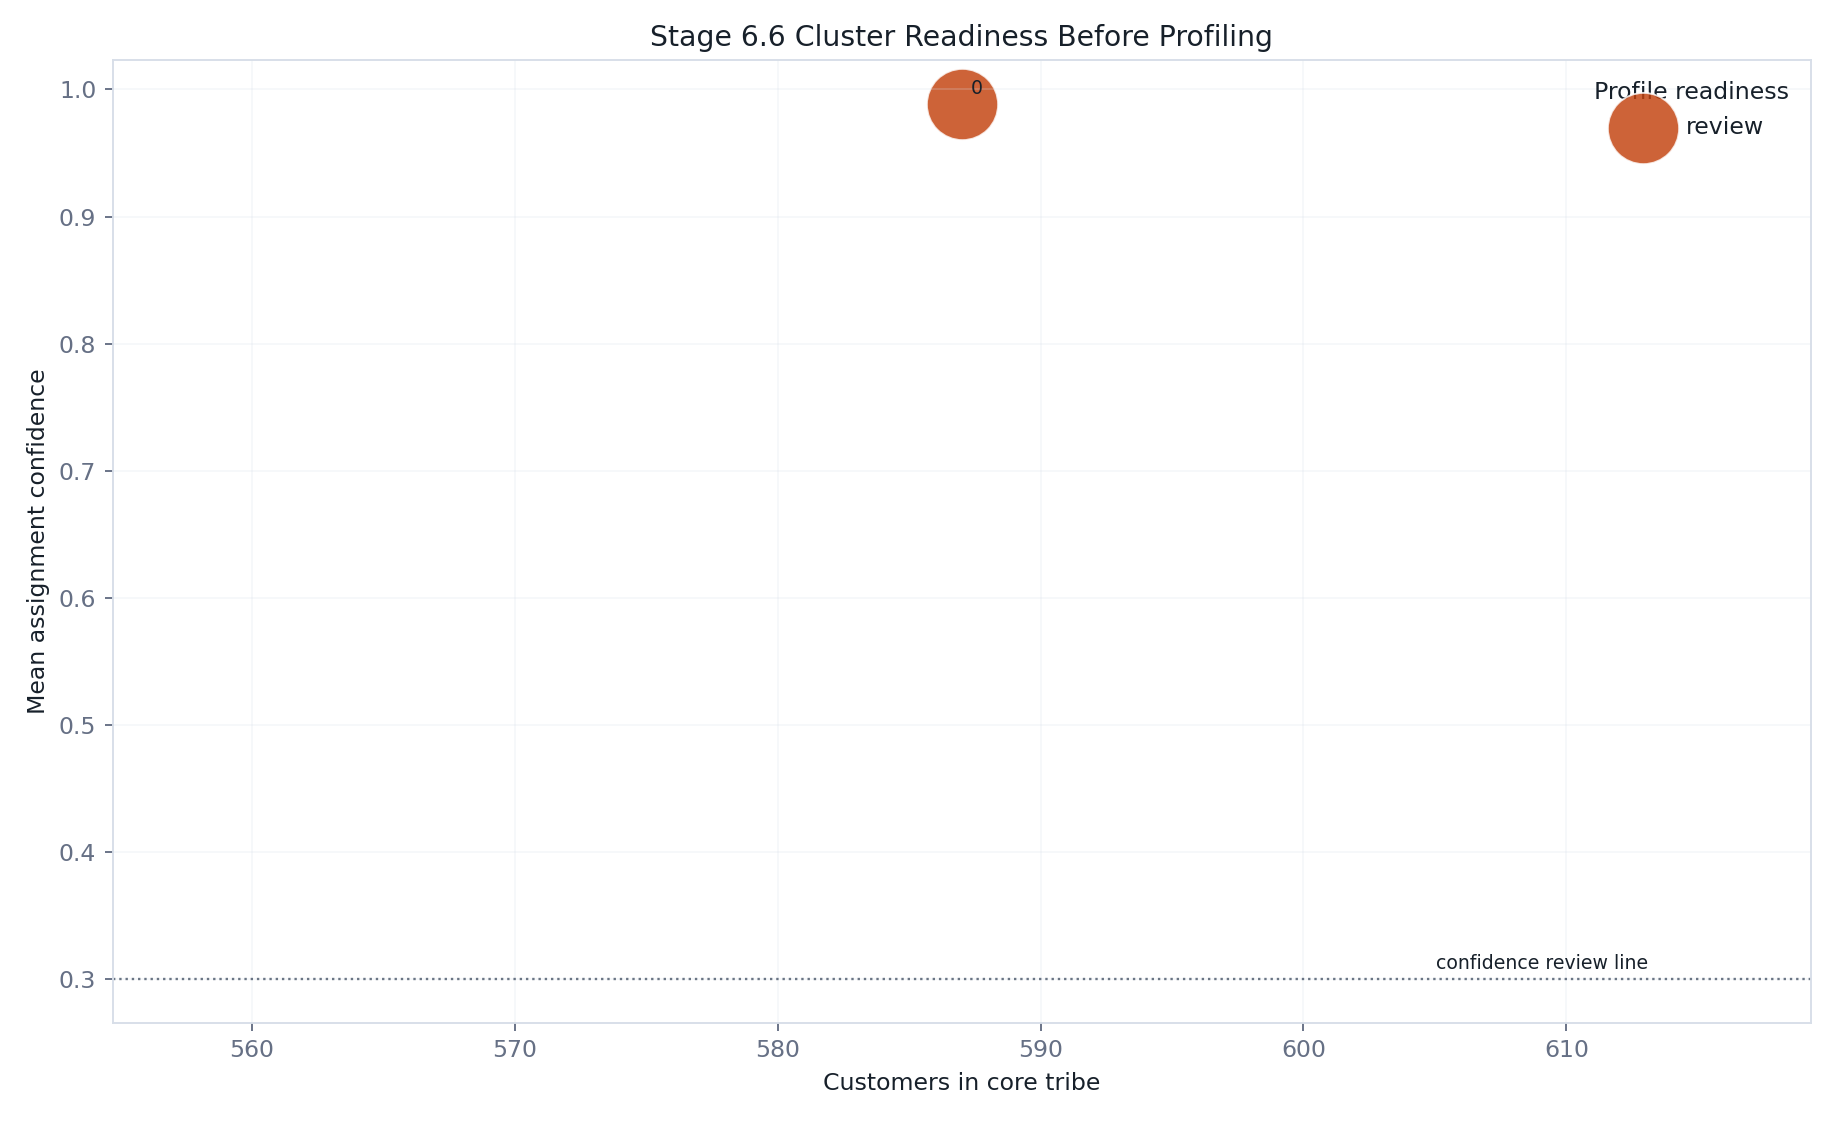

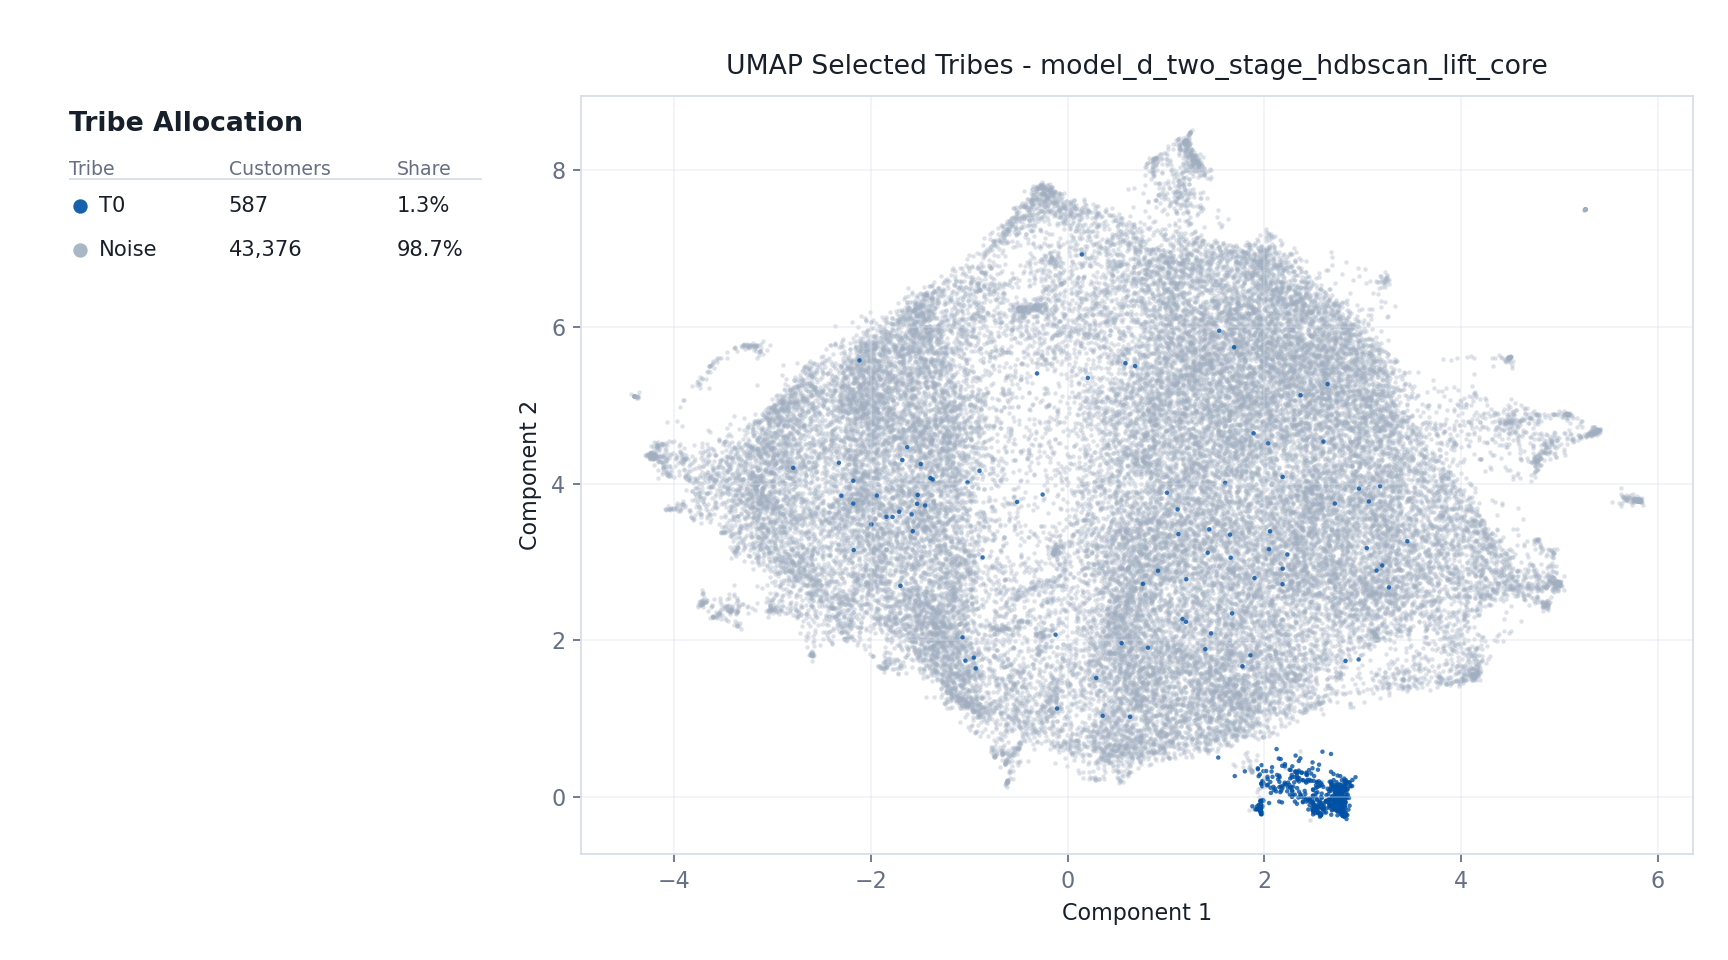

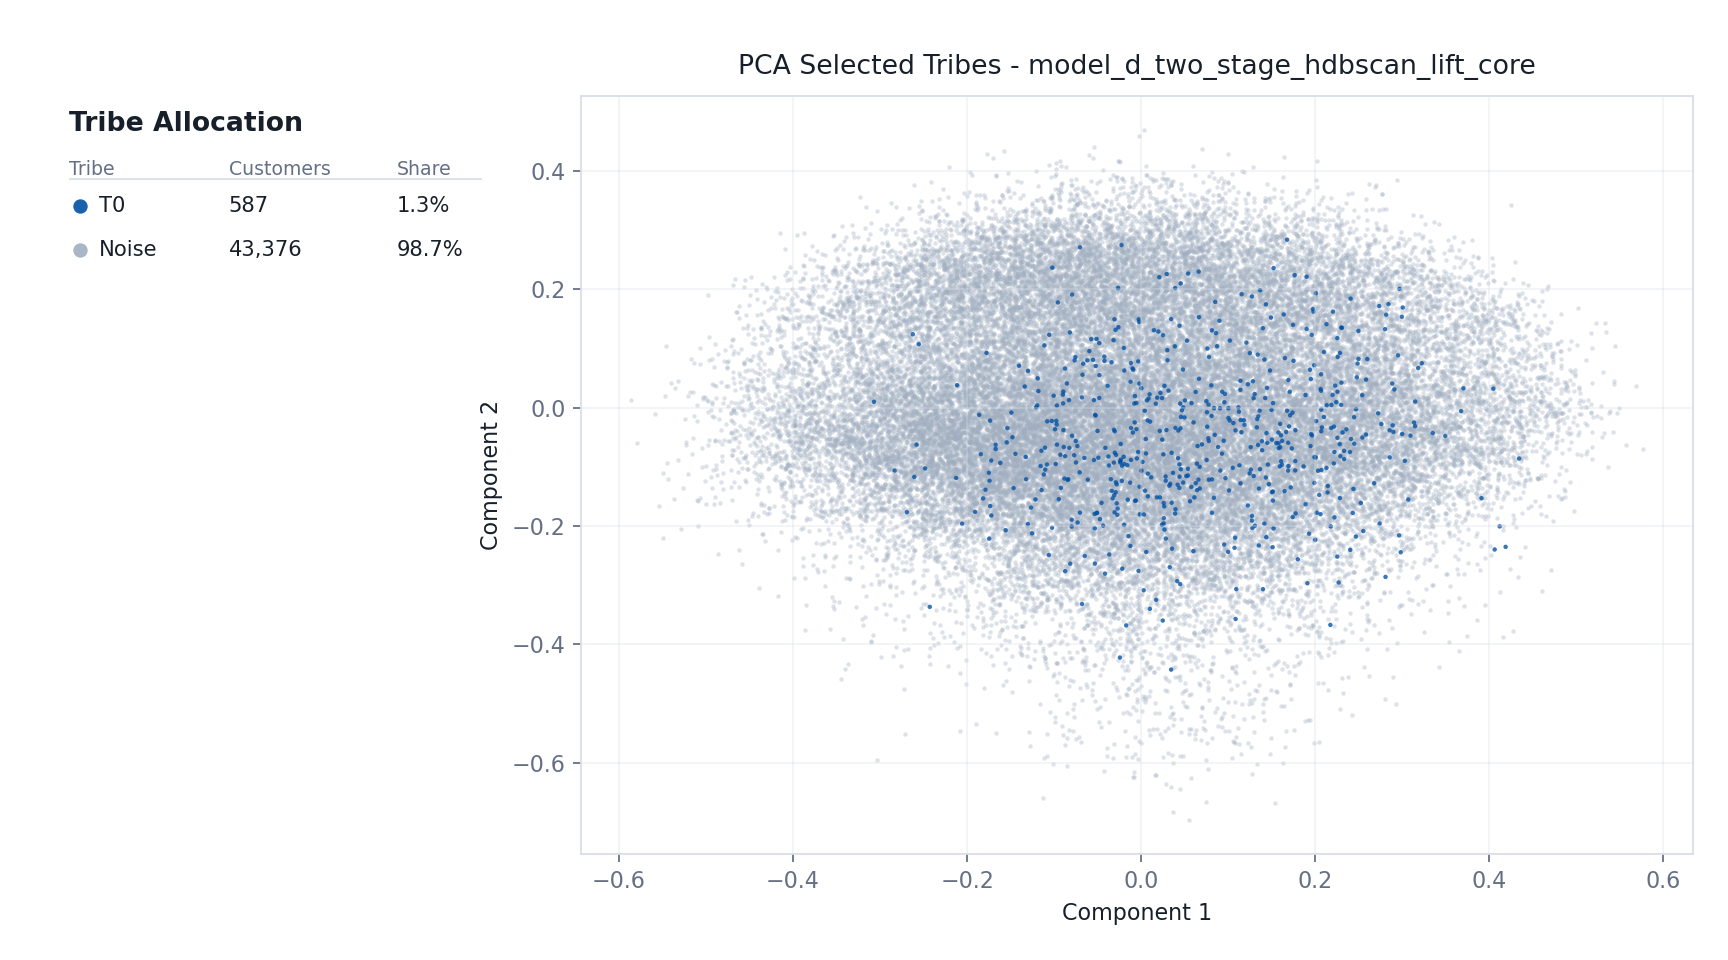

In [ ]:
from IPython.display import Image, display
import polars as pl

from src.cluster_validation import build_cluster_validity_stability_report
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import build_2d_projection_figures, plot_stage6_cluster_readiness

cluster_stability = build_cluster_validity_stability_report(
    model_suite,
    feature_sets[selection_feature_set],
    output_path=CONFIG.artifacts / "stage6" / "stage6_6_cluster_stability_readiness.parquet",
    cfg=CONFIG,
)

stability_table = pl.read_csv(cluster_stability["summary_csv"]).select([
    "candidate_id",
    "cluster_count",
    "noise_pct",
    "cluster_size_cv",
    "jitter_ari_mean",
    "jitter_ari_std",
    "jitter_label_recovery_accuracy_mean",
    "validity_note",
])
stage6_winner_key = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")[0, "candidate_id"]
stage6_6_winner_stability = stability_table.filter(pl.col("candidate_id") == stage6_winner_key)
cluster_readiness_table = pl.read_csv(cluster_stability["cluster_summary_csv"])
stage6_6_cluster_readiness = cluster_readiness_table.filter(pl.col("candidate_id") == stage6_winner_key)

stage6_6_projection_dir = CONFIG.figures
stage6_6_projection_figures = build_2d_projection_figures(
    feature_sets[selection_feature_set],
    model_suite["assignment_paths"][stage6_winner_key],
    output_dir=stage6_6_projection_dir,
    output_prefix="stage_06_6_winner_projection",
    stage_label="Stage 6.6 figures",
    cfg=CONFIG,
)
stage6_6_cluster_readiness_figure = plot_stage6_cluster_readiness(
    cluster_stability["cluster_summary_csv"],
    output_path=CONFIG.figures / "stage6_6_cluster_readiness.png",
    title="Stage 6.6 Cluster Readiness Before Profiling",
    cfg=CONFIG,
)
stage6_6_metrics_row = stage6_6_winner_stability.row(0, named=True)
stage6_6_report_metrics = [
    ("cluster_count", stage6_6_metrics_row.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_6_metrics_row.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("cluster_size_cv", stage6_6_metrics_row.get("cluster_size_cv"), "<= 1.5 gate; lower is more balanced"),
    ("jitter_ari_mean", stage6_6_metrics_row.get("jitter_ari_mean"), ">= 0.80 strong; >= 0.60 usable"),
    ("jitter_label_recovery_accuracy_mean", stage6_6_metrics_row.get("jitter_label_recovery_accuracy_mean"), ">= 0.85 strong; >= 0.70 usable"),
    ("clusters_marked_review", stage6_6_cluster_readiness.filter(pl.col("profile_readiness") == "review").height, "0 ideal; review before profiling if > 0"),
    ("clusters_marked_usable_or_strong", stage6_6_cluster_readiness.filter(pl.col("profile_readiness").is_in(["usable", "strong"])).height, "all retained clusters"),
]
stage6_6_report = write_stage_report(
    "06_6",
    "Cluster Stability and Profile Readiness",
    summary=[
        f"Stage 6 winner checked: {stage6_winner_key}",
        "Stage 6.6 focuses on the retained merged clusters themselves: stability, confidence, size, and readiness for profiling.",
        "This is the technical gate before Stage 7 product-lift interpretation.",
    ],
    metrics=stage6_6_report_metrics,
    figures={
        "Cluster readiness": stage6_6_cluster_readiness_figure,
        "PCA projection": stage6_6_projection_figures.get("pca"),
        "UMAP projection": stage6_6_projection_figures.get("umap"),
    },
    artifacts={
        "Stability/readiness parquet": cluster_stability["parquet"],
        "Stability/readiness summary CSV": cluster_stability["summary_csv"],
        "Cluster readiness parquet": cluster_stability["cluster_parquet"],
        "Cluster readiness summary CSV": cluster_stability["cluster_summary_csv"],
        "Projection figures root": stage6_6_projection_dir,
    },
    cfg=CONFIG,
    max_metric_rows=16,
)
display_stage_report(stage6_6_report)
display(stability_table.head(20))
display(stage6_6_winner_stability)
display(stage6_6_cluster_readiness.select([
    "tribe_id",
    "customers",
    "customer_share_pct",
    "mean_assignment_confidence",
    "p10_assignment_confidence",
    "jitter_label_recovery_accuracy_mean",
    "profile_readiness",
    "readiness_issues",
]).sort("tribe_id"))
display(Image(filename=str(stage6_6_cluster_readiness_figure)))
if "umap" in stage6_6_projection_figures:
    display(Image(filename=str(stage6_6_projection_figures["umap"])))
display(Image(filename=str(stage6_6_projection_figures["pca"])))


<a id="stage-7"></a>

## Stage 7: Final Tribe Handoff

Stage 7 is the handoff stage. It profiles the selected hard HDBSCAN solution once, then writes a compact final pack: one story, one sortable index, one PNG card per tribe, and a small set of supporting proof tables. The point is to make the finished run easy to read after the kernel stops, not to bury the result in loosely related files.

Read Stage 7 as an evidence ladder:

| Step | Question | Evidence |
|---|---|---|
| 1. Selected solution | Which clustering result are we explaining? | Stage 6 ranked winner and hard HDBSCAN assignment |
| 2. Technical trust | Are the tribes stable enough to interpret? | Stage 6.6 readiness, confidence, perturbation checks |
| 3. Product identity | What should this tribe be called? | Lifted products, lift-vs-rest, q-values, customer coverage |
| 4. Commercial context | What does the tribe look like operationally? | Customers, spend statistics, visit frequency, basket value, promo share |
| 5. Caveats | What must not be overstated? | Readiness issues, label confidence, purchase-only guardrails |

The production-safe Stage 7 cell does not run the old raw-noise audit, per-customer subsegment tagging, clustering atlas, or legacy LLM prompt pack. Those are optional investigations; they should live outside the final handoff path because they rescan heavy inputs and make the last stage hard to reason about.

Optional LLM synthesis is now part of the Stage 7 profile builder. The evidence profile is always written first; when the configured provider key is available in the environment or `.env`, Stage 7 reruns the profile with LLM labels and interpretation added without changing clustering, readiness, or final promotion.

Working tribe names are deterministic review labels from product-purchase evidence. Spend and visit KPIs appear only as post-clustering context, never as modeling signal.


In [ ]:
import polars as pl
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display

from src.profiling import (
    profile_quality_summary,
    profile_readiness_evidence_table,
    profile_tribes,
    write_stage7_final_handoff_pack,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_tribe_vs_population_evidence_dashboard

stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_winner = stage6_ranked.row(0, named=True)
selected_key = stage6_winner["candidate_id"]
selected_assignment_path = model_suite["assignment_paths"][selected_key]

stage7_artifacts_dir = CONFIG.artifacts / "stage7"
stage7_figures_dir = CONFIG.figures
stage7_artifacts_dir.mkdir(parents=True, exist_ok=True)
stage7_figures_dir.mkdir(parents=True, exist_ok=True)

load_dotenv(CONFIG.root / ".env", override=False)
llm_provider = str(CONFIG.get("llm_analysis.provider", "gemini")).lower()
llm_key_env = "ANTHROPIC_API_KEY" if llm_provider in {"anthropic", "claude"} else str(CONFIG.get("llm_analysis.api_key_env", "GEMINI_API_KEY"))
llm_model = str(CONFIG.get("llm_analysis.model", "gemini-3.5-flash")) if llm_provider == "gemini" else "claude-sonnet-4-6"
llm_api_key = os.getenv(llm_key_env, "")
selected_profile_path = profile_tribes(
    assignments_path=selected_assignment_path,
    transactions=transactions,
    behavior_path=behavior_path,
    enable_llm=False,
    force=False,
    cfg=CONFIG,
)
if llm_api_key:
    selected_profile_path = profile_tribes(
        assignments_path=selected_assignment_path,
        transactions=transactions,
        behavior_path=behavior_path,
        enable_llm=True,
        llm_api_key=llm_api_key,
        llm_provider=llm_provider,
        llm_model=llm_model,
        force=True,
        cfg=CONFIG,
    )
profile_paths = {selected_key: selected_profile_path}
profile_preview = pl.read_parquet(selected_profile_path)
stage7_llm_status = (
    profile_preview.get_column("llm_status").value_counts().to_dicts()
    if "llm_status" in profile_preview.columns
    else []
)

cluster_readiness_source = cluster_stability.get("cluster_summary_csv") if "cluster_stability" in globals() else None
stage7_quality = profile_quality_summary(selected_profile_path, cfg=CONFIG)
stage7_readiness_path = stage7_artifacts_dir / f"stage7_profile_readiness_evidence_{CONFIG.mode}.csv"
stage7_readiness = profile_readiness_evidence_table(
    selected_profile_path,
    cluster_readiness_path=cluster_readiness_source,
    output_csv=stage7_readiness_path,
    cfg=CONFIG,
)
stage7_ready_clusters = stage7_readiness.filter(pl.col("profiling_readiness").is_in(["ready", "ready_strong"])).height
stage7_review_clusters = stage7_readiness.filter(pl.col("profiling_readiness") == "review").height

stage7_final_pack = write_stage7_final_handoff_pack(
    selected_profile_path,
    assignments_path=selected_assignment_path,
    cluster_readiness_path=cluster_readiness_source,
    readiness_path=stage7_readiness_path,
    behavior_path=behavior_path if "behavior_path" in globals() else None,
    output_dir=stage7_artifacts_dir / "final_handoff",
    write_cards=True,
    cfg=CONFIG,
)
stage7_final_index = pl.read_csv(stage7_final_pack["index_csv"])
stage7_card_paths = stage7_final_pack["card_paths"]
stage7_card_count = len(stage7_card_paths)
stage7_final_tribes = stage7_final_index.height
stage7_review_candidates_path = stage7_final_pack["review_candidates_csv"]
stage7_review_candidates = pl.read_csv(stage7_review_candidates_path)
stage7_customer_metric_tests_path = stage7_final_pack["customer_metric_tests_csv"]
stage7_customer_metric_tests = pl.read_csv(stage7_customer_metric_tests_path)
stage7_llm_evidence_path = stage7_final_pack["llm_evidence_csv"]
q_threshold = float(CONFIG.get("profiling.significance_q_threshold", 0.05))
stage7_significant_customer_metric_tests = (
    stage7_customer_metric_tests.filter(pl.col("anova_q_value") <= q_threshold).height
    if not stage7_customer_metric_tests.is_empty() and "anova_q_value" in stage7_customer_metric_tests.columns
    else 0
)

tribe_vs_population_dashboard = plot_tribe_vs_population_evidence_dashboard(
    selected_profile_path,
    output_path=stage7_figures_dir / f"stage_07_tribe_vs_population_evidence_dashboard_{CONFIG.mode}.png",
    cfg=CONFIG,
)

stage7_model_table = pl.DataFrame([
    {
        "stage6_rank": stage6_winner.get("stage6_rank"),
        "candidate_id": selected_key,
        "cluster_count": stage6_winner.get("cluster_count"),
        "profile_path": str(selected_profile_path),
        "final_story": str(stage7_final_pack["story_markdown"]),
        "final_index": str(stage7_final_pack["index_csv"]),
        "tribe_cards": str(stage7_final_pack["card_directory"]),
    }
])
stage7_report = write_stage_report(
    "07",
    "Final Tribe Handoff",
    summary=[
        f"Profiled selected Stage 6 model: {selected_key}",
        "Created an organized final handoff folder that promotes only configured final-ready, product-actionable tribes into the final index and PNG card gallery.",
        "Clusters below the final-readiness bar remain visible in the review-candidates appendix, not in the final tribe story.",
        "After the profile parquet is built, the final handoff uses aggregate profiles and behavior summaries instead of rescanning raw transactions.",
        "Tribe labels and interpretations come from product lift, co-purchase, temporal, behavior, and loyalty evidence.",
        f"Optional {llm_provider} synthesis status: {stage7_llm_status}",
    ],
    metrics=[
        ("profiled_candidate_tribes", stage7_quality.get("profiled_clusters"), "all retained Stage 6 clusters reviewed"),
        ("final_promoted_tribes", stage7_final_tribes, "only configured final-readiness statuses"),
        ("tribe_cards", stage7_card_count, "one PNG card per final promoted tribe"),
        ("profile_ready_clusters", stage7_ready_clusters, "diagnostic ready/ready_strong count"),
        ("review_candidate_clusters", stage7_review_candidates.height, "held out of final tribe story"),
        ("clusters_with_significant_product_lift", stage7_quality.get("clusters_with_significant_product_lift"), "most tribes; q<=0.05"),
        ("avg_significant_product_lifts_per_cluster", stage7_quality.get("avg_significant_product_lifts_per_cluster"), ">=1.0 preferred"),
        ("avg_max_product_lift_vs_rest", stage7_quality.get("avg_max_product_lift_vs_rest"), ">1.5 indicates clear over-indexing"),
        ("customer_metric_anova_tests", stage7_customer_metric_tests.height, "customer-level context only"),
        ("significant_customer_metric_anova_tests", stage7_significant_customer_metric_tests, "q<=0.05 after FDR"),
        ("llm_synthesis_status", stage7_llm_status, f"success only when {llm_key_env} is set"),
    ],
    figures={
        "Tribe vs population dashboard": tribe_vs_population_dashboard,
        "Tribe card directory": stage7_final_pack["card_directory"],
    },
    artifacts={
        "Final story MD": stage7_final_pack["story_markdown"],
        "Final story HTML": stage7_final_pack["story_html"],
        "Final index CSV": stage7_final_pack["index_csv"],
        "Final manifest": stage7_final_pack["manifest_json"],
        "Selected profile parquet": selected_profile_path,
        "Profile readiness evidence": stage7_final_pack["readiness_csv"],
        "Review candidates appendix": stage7_review_candidates_path,
        "Product summary long table": stage7_final_pack["product_summary_paths"]["combined_csv"],
        "LLM evidence long CSV": stage7_llm_evidence_path,
        "All-tribe comparison HTML": stage7_final_pack["comparison_paths"]["html"],
        "Customer metric context": stage7_customer_metric_tests_path,
    },
    cfg=CONFIG,
    max_metric_rows=14,
)

display_stage_report(stage7_report, max_lines=80)
display(stage7_model_table)
display(Markdown(
    f"### Stage 7 Final Handoff\n\n"
    f"Final story: {stage7_final_pack['story_markdown']}  \n"
    f"Readable HTML: {stage7_final_pack['story_html']}  \n"
    f"Tribe cards: {stage7_final_pack['card_directory']}  \n"
    f"Final promoted tribes: {stage7_final_tribes}; review candidates held out: {stage7_review_candidates.height}.  \n"
    f"LLM synthesis status: **{stage7_llm_status}**  \n"
    "Start with the card gallery, then use the final index and supporting tables to defend each promoted label."
))
display(Markdown(
    "### Optional LLM Synthesis\n\n"
    f"- Provider: `{llm_provider}`\n"
    f"- Key env: `{llm_key_env}`\n"
    f"- Status counts: `{stage7_llm_status}`\n"
    "- Boundary: optional Stage 7 enrichment only; no clustering, filtering, readiness, or promotion changes."
))
display(stage7_final_index)
if not stage7_review_candidates.is_empty():
    display(Markdown("### Review Candidates Held Out Of Final Story"))
    display(stage7_review_candidates)
display(Image(filename=str(tribe_vs_population_dashboard)))
first_card = next(iter(stage7_card_paths.values()), None)
if first_card is not None:
    display(Markdown("### Example Tribe Card"))
    display(Image(filename=str(first_card)))

display(Markdown(
    "### Supporting Evidence\n\n"
    f"- Final index: {stage7_final_pack['index_csv']}\n"
    f"- Product summaries: {stage7_final_pack['product_summary_paths']['directory']}\n"
    f"- Tribe comparison: {stage7_final_pack['comparison_paths']['html']}\n"
    f"- LLM evidence: {stage7_llm_evidence_path}\n"
    f"- Manifest and memory policy: {stage7_final_pack['manifest_json']}"
))

selected_profile_path


[13:11:05] Stage 7 profiling: building tribe profile | assignments=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_d_two_stage_hdbscan_lift_core.parquet
[13:11:05] Stage 7 profiling: assignment population | clusters=1, customers=43963, noise_customers=43376, model=model_d_two_stage_hdbscan_lift_core, variant=two_stage_u20_n75_eom_mcs550_ms2_stage1_mcs550_ms2_eom_stage2_mcs700_ms2_eom_lift
[13:11:05] Stage 7 profiling: aggregating population product counts | min_product_customers=10
[13:11:06] Stage 7 profiling: aggregating product metadata
[13:11:06] Stage 7 profiling: population product counts ready | products=77992
[13:11:06] Stage 7 profiling: aggregating tribe product lifts
[13:11:07] Stage 7 profiling: tribe product lifts ready | rows=1143
[13:11:07] Stage 7 profiling: building product theme map
[13:11:15] Stage 7 profiling: product theme map ready | rows=64524
[13:11:15] Stage 7 profiling: aggregating population t

ComputeError: cannot compare string with numeric type (f64)

This error occurred in the following expression:
	[(col("anova_q_value")) <= (dyn float: 0.05)]
